In [1]:
import coderdata as cd
import os
import numpy as np
import pandas as pd
from umap import UMAP
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator  # Correct import for new RDKit
import pubchempy as pcp
import coderdata_processing
import importlib
import torch
from torch.utils.data import TensorDataset

/home/dzhao268/anaconda3/envs/jax_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
datasets = ["beataml", "bladder", "ccle", "colorectal", "ctrpv2", "fimm", "gcsi", "gdscv1", "gdscv2", "liver", "mpnst", "nci60", "pancreatic", "prism"]

data_path = '../data/Cancer/coderdata/'

loaded_datasets = {}
for data_name in datasets:
    print(f"Loading dataset: {data_name}")
    loaded_datasets[data_name] = cd.load(name=data_name, local_path=data_path)

Loading dataset: beataml


Importing raw data ...
Importing 'transcriptomics' from ../data/Cancer/coderdata/beataml_transcriptomics.csv.gz ... DONE
Importing 'proteomics' from ../data/Cancer/coderdata/beataml_proteomics.csv.gz ... DONE
Importing 'mutations' from ../data/Cancer/coderdata/beataml_mutations.csv.gz ... DONE
'copy_number' not available for beataml
Importing 'samples' from ../data/Cancer/coderdata/beataml_samples.csv ... DONE
Importing 'drugs' from ../data/Cancer/coderdata/beataml_drugs.tsv.gz ... DONE
Importing 'drug_descriptors' from ../data/Cancer/coderdata/beataml_drug_descriptors.tsv.gz ... DONE
'mirna' not available for beataml
Importing 'experiments' from ../data/Cancer/coderdata/beataml_experiments.tsv.gz ... DONE
'methylation' not available for beataml
'metabolomics' not available for beataml
Importing 'genes' from ../data/Cancer/coderdata/genes.csv.gz ... DONE
Importing raw data ... DONE
Importing raw data ...
Importing 'transcriptomics' from ../data/Cancer/coderdata/bladder_transcriptomics.

Loading dataset: bladder


DONE
'proteomics' not available for bladder
Importing 'mutations' from ../data/Cancer/coderdata/bladder_mutations.csv.gz ... DONE
Importing 'copy_number' from ../data/Cancer/coderdata/bladder_copy_number.csv.gz ... DONE
Importing 'samples' from ../data/Cancer/coderdata/bladder_samples.csv ... DONE
Importing 'drugs' from ../data/Cancer/coderdata/bladder_drugs.tsv.gz ... DONE
Importing 'drug_descriptors' from ../data/Cancer/coderdata/bladder_drug_descriptors.tsv.gz ... DONE
'mirna' not available for bladder
Importing 'experiments' from ../data/Cancer/coderdata/bladder_experiments.tsv.gz ... DONE
'methylation' not available for bladder
'metabolomics' not available for bladder
Importing 'genes' from ../data/Cancer/coderdata/genes.csv.gz ... DONE
Importing raw data ... DONE
Importing raw data ...
Importing 'transcriptomics' from ../data/Cancer/coderdata/ccle_transcriptomics.csv.gz ... 

Loading dataset: ccle


...

DONE
Importing 'proteomics' from ../data/Cancer/coderdata/nci60_proteomics.csv.gz ... DONE
Importing 'mutations' from ../data/Cancer/coderdata/nci60_mutations.csv.gz ... DONE
Importing 'copy_number' from ../data/Cancer/coderdata/nci60_copy_number.csv.gz ... DONE
Importing 'samples' from ../data/Cancer/coderdata/nci60_samples.csv ... DONE
Importing 'drugs' from ../data/Cancer/coderdata/nci60_drugs.tsv.gz ... DONE
Importing 'drug_descriptors' from ../data/Cancer/coderdata/nci60_drug_descriptors.tsv.gz ... DONE
'mirna' not available for nci60
Importing 'experiments' from ../data/Cancer/coderdata/nci60_experiments.tsv.gz ... DONE
'methylation' not available for nci60
'metabolomics' not available for nci60
Importing 'genes' from ../data/Cancer/coderdata/genes.csv.gz ... DONE
Importing raw data ... DONE
Importing raw data ...
Importing 'transcriptomics' from ../data/Cancer/coderdata/pancreatic_transcriptomics.csv.gz ... 

Loading dataset: pancreatic


DONE
'proteomics' not available for pancreatic
Importing 'mutations' from ../data/Cancer/coderdata/pancreatic_mutations.csv.gz ... DONE
Importing 'copy_number' from ../data/Cancer/coderdata/pancreatic_copy_number.csv.gz ... DONE
Importing 'samples' from ../data/Cancer/coderdata/pancreatic_samples.csv ... DONE
Importing 'drugs' from ../data/Cancer/coderdata/pancreatic_drugs.tsv.gz ... DONE
Importing 'drug_descriptors' from ../data/Cancer/coderdata/pancreatic_drug_descriptors.tsv.gz ... DONE
'mirna' not available for pancreatic
Importing 'experiments' from ../data/Cancer/coderdata/pancreatic_experiments.tsv.gz ... DONE
'methylation' not available for pancreatic
'metabolomics' not available for pancreatic
Importing 'genes' from ../data/Cancer/coderdata/genes.csv.gz ... DONE
Importing raw data ... DONE
Importing raw data ...
Importing 'transcriptomics' from ../data/Cancer/coderdata/prism_transcriptomics.csv.gz ... 

Loading dataset: prism


DONE
Importing 'proteomics' from ../data/Cancer/coderdata/prism_proteomics.csv.gz ... DONE
Importing 'mutations' from ../data/Cancer/coderdata/prism_mutations.csv.gz ... DONE
Importing 'copy_number' from ../data/Cancer/coderdata/prism_copy_number.csv.gz ... DONE
Importing 'samples' from ../data/Cancer/coderdata/prism_samples.csv ... DONE
Importing 'drugs' from ../data/Cancer/coderdata/prism_drugs.tsv.gz ... DONE
Importing 'drug_descriptors' from ../data/Cancer/coderdata/prism_drug_descriptors.tsv.gz ... DONE
'mirna' not available for prism
Importing 'experiments' from ../data/Cancer/coderdata/prism_experiments.tsv.gz ... DONE
'methylation' not available for prism
'metabolomics' not available for prism
Importing 'genes' from ../data/Cancer/coderdata/genes.csv.gz ... DONE
Importing raw data ... DONE


In [3]:
include_copy_number = False
include_proteomics = False

to_remove = ["cptac", "hcmi"]
if (include_copy_number):
    new_to_remove = ["beataml", "sarcoma"]
    to_remove = list(set(to_remove + new_to_remove))

if (include_proteomics):
    new_to_remove = ["bladder", "colorectal", "novartis", "pancreatic", "sarcoma"]
    to_remove = list(set(to_remove + new_to_remove))

selected_datasets = {x: loaded_datasets[x] for x in datasets if x not in to_remove}

In [ ]:
importlib.reload(coderdata_processing)
from coderdata_processing import unify_feature_across_dataset, get_total_mutation_types, get_cell_id_across_dfs

unified_datasets = {}
data_size_ref = {}
# for mutations, need to get total mutation variation types
all_mutation_types = get_total_mutation_types(selected_datasets)
for mut_type in all_mutation_types:
    unified_datasets[f"mutations_{mut_type}"] = unify_feature_across_dataset(selected_datasets, feature="mutations", mutation_type=mut_type)

for dataset in selected_datasets.keys():
    for mut_type in all_mutation_types:
        if dataset not in data_size_ref:
            data_size_ref[dataset] = unified_datasets[f"mutations_{mut_type}"][dataset].shape[0]
        else:
            data_size_ref[dataset] = max(data_size_ref[dataset], unified_datasets[f"mutations_{mut_type}"][dataset].shape[0])
print(f"Unified features {unified_datasets.keys()} across datasets.")

print(data_size_ref)

Unified features dict_keys(['mutations_Protein_Altering_Variant', 'mutations_Frame_Shift_Ins', 'mutations_Stop_Codon_Del', 'mutations_Frameshift_Variant', 'mutations_Intron', "mutations_5'Flank", "mutations_3'Flank", 'mutations_Stop_Codon_Ins', 'mutations_Nonstop_Mutation', 'mutations_Missense_Mutation', 'mutations_Splice_Site', 'mutations_In_Frame_Ins', 'mutations_Splice_Region', 'mutations_Start_Codon_Ins', 'mutations_Frame_Shift_Del', 'mutations_Translation_Start_Site', 'mutations_IGR', 'mutations_Nonsense_Mutation', 'mutations_RNA', 'mutations_Start_Codon_Del', 'mutations_Start_Codon_SNP', 'mutations_In_Frame_Del', "mutations_3'UTR", 'mutations_Silent', "mutations_5'UTR"]) across datasets.
{'beataml': 823, 'bladder': 130, 'ccle': 484, 'colorectal': 38, 'ctrpv2': 821, 'fimm': 51, 'gcsi': 558, 'gdscv1': 966, 'gdscv2': 793, 'liver': 62, 'mpnst': 29, 'nci60': 77, 'pancreatic': 48, 'prism': 476}


Feature mutations_IGR, Dataset beataml: Adding 868 missing samples as part of total samples 868.
Feature mutations_IGR, Dataset bladder: Adding 130 missing samples as part of total samples 130.
Feature mutations_IGR, Dataset ccle: Adding 484 missing samples as part of total samples 484.
Feature mutations_IGR, Dataset colorectal: Adding 1 missing samples as part of total samples 38.
Feature mutations_IGR, Dataset ctrpv2: Adding 821 missing samples as part of total samples 821.
Feature mutations_IGR, Dataset fimm: Adding 51 missing samples as part of total samples 51.
Feature mutations_IGR, Dataset gcsi: Adding 558 missing samples as part of total samples 558.
Feature mutations_IGR, Dataset gdscv1: Adding 966 missing samples as part of total samples 966.
Feature mutations_IGR, Dataset gdscv2: Adding 793 missing samples as part of total samples 793.
Feature mutations_IGR, Dataset liver: Adding 62 missing samples as part of total samples 62.
Feature mutations_IGR, Dataset mpnst: Adding 29 

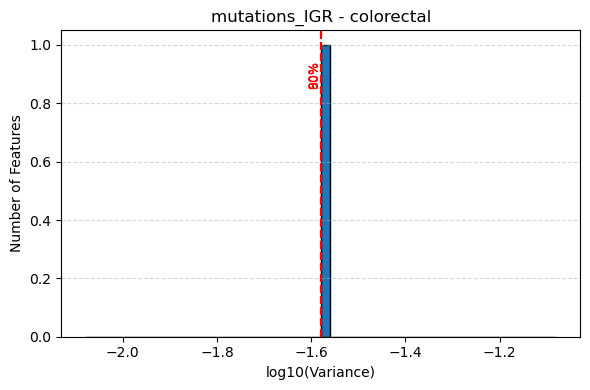

   ⚠️ ctrpv2: Removed 1 non-positive variances before log10 transform
   ⚠️ Skipping mutations_IGR - ctrpv2: no positive variances to plot
   ⚠️ fimm: Removed 1 non-positive variances before log10 transform
   ⚠️ Skipping mutations_IGR - fimm: no positive variances to plot
   ⚠️ gcsi: Removed 1 non-positive variances before log10 transform
   ⚠️ Skipping mutations_IGR - gcsi: no positive variances to plot
   ⚠️ gdscv1: Removed 1 non-positive variances before log10 transform
   ⚠️ Skipping mutations_IGR - gdscv1: no positive variances to plot
   ⚠️ gdscv2: Removed 1 non-positive variances before log10 transform
   ⚠️ Skipping mutations_IGR - gdscv2: no positive variances to plot
   ⚠️ liver: Removed 1 non-positive variances before log10 transform
   ⚠️ Skipping mutations_IGR - liver: no positive variances to plot
   ⚠️ mpnst: Removed 1 non-positive variances before log10 transform
   ⚠️ Skipping mutations_IGR - mpnst: no positive variances to plot
   ⚠️ nci60: Removed 1 non-positive var

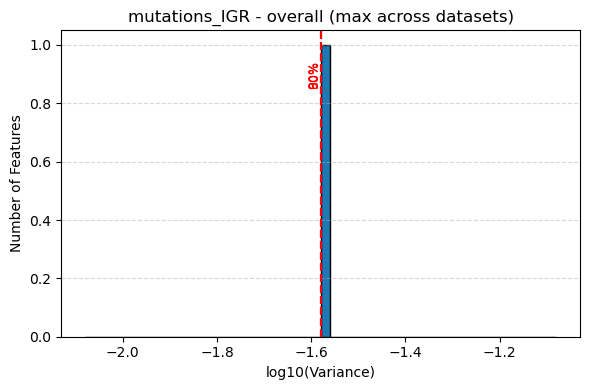

📊 Plotting variance distribution for feature group: mutations_5'UTR
   ⚠️ beataml: Removed 13852 non-positive variances before log10 transform
   ⚠️ Skipping mutations_5'UTR - beataml: no positive variances to plot
   ⚠️ bladder: Removed 13851 non-positive variances before log10 transform


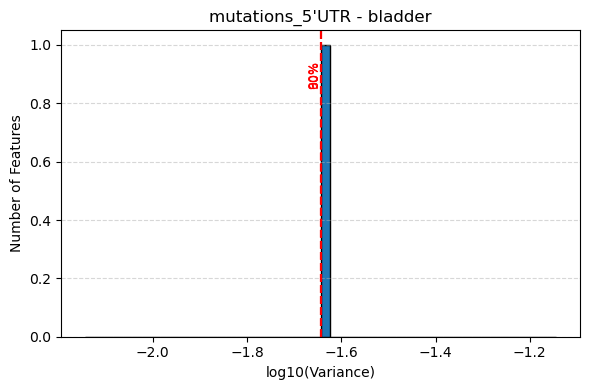

   ⚠️ ccle: Removed 13852 non-positive variances before log10 transform
   ⚠️ Skipping mutations_5'UTR - ccle: no positive variances to plot
   ⚠️ colorectal: Removed 13092 non-positive variances before log10 transform


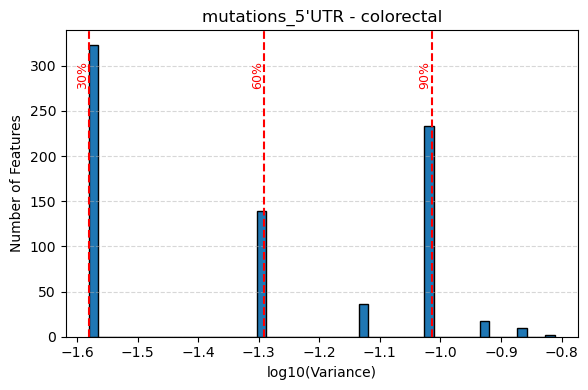

   ⚠️ ctrpv2: Removed 13852 non-positive variances before log10 transform
   ⚠️ Skipping mutations_5'UTR - ctrpv2: no positive variances to plot
   ⚠️ fimm: Removed 13852 non-positive variances before log10 transform
   ⚠️ Skipping mutations_5'UTR - fimm: no positive variances to plot
   ⚠️ gcsi: Removed 13852 non-positive variances before log10 transform
   ⚠️ Skipping mutations_5'UTR - gcsi: no positive variances to plot
   ⚠️ gdscv1: Removed 629 non-positive variances before log10 transform


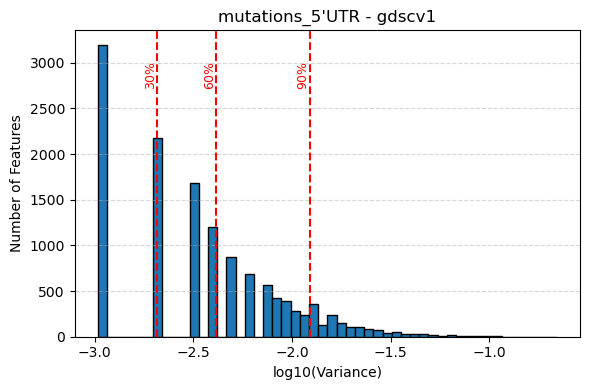

   ⚠️ gdscv2: Removed 1156 non-positive variances before log10 transform


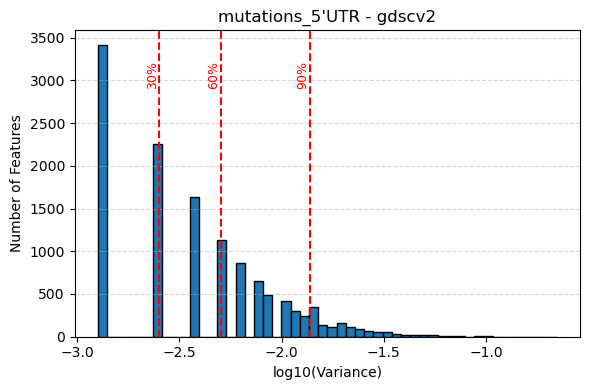

   ⚠️ liver: Removed 13852 non-positive variances before log10 transform
   ⚠️ Skipping mutations_5'UTR - liver: no positive variances to plot
   ⚠️ mpnst: Removed 12972 non-positive variances before log10 transform


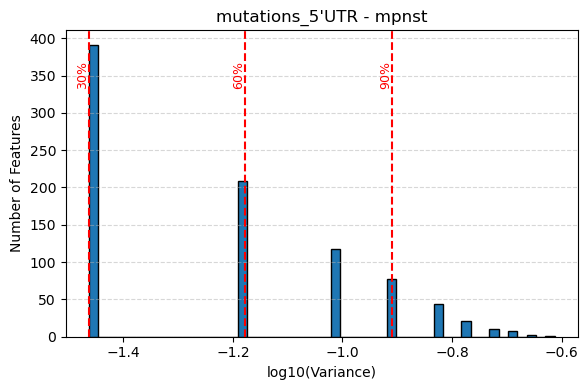

   ⚠️ nci60: Removed 13852 non-positive variances before log10 transform
   ⚠️ Skipping mutations_5'UTR - nci60: no positive variances to plot
   ⚠️ pancreatic: Removed 12130 non-positive variances before log10 transform


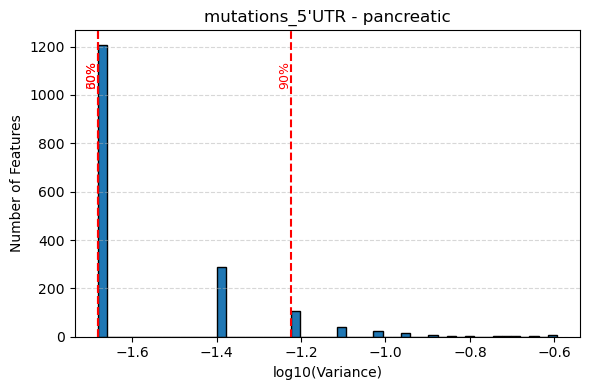

   ⚠️ prism: Removed 13852 non-positive variances before log10 transform
   ⚠️ Skipping mutations_5'UTR - prism: no positive variances to plot


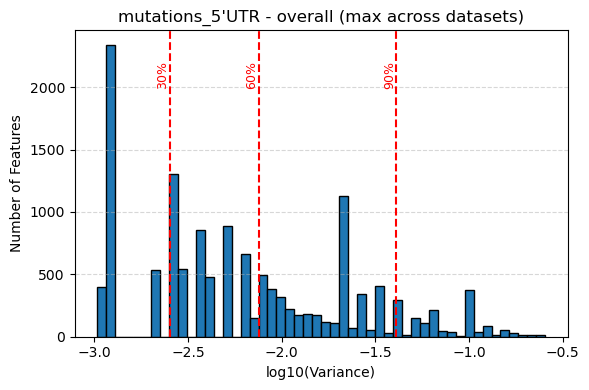

📊 Plotting variance distribution for feature group: mutations_Missense_Mutation
   ⚠️ beataml: Removed 16470 non-positive variances before log10 transform


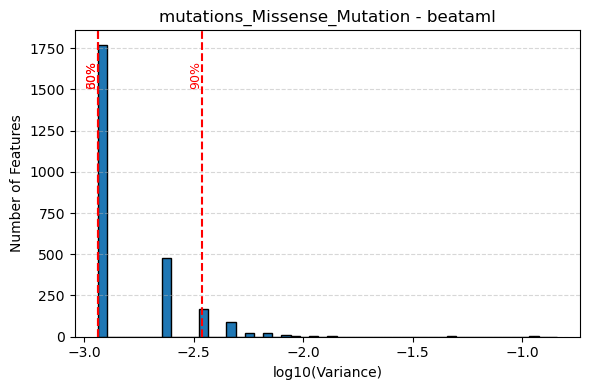

   ⚠️ bladder: Removed 18820 non-positive variances before log10 transform


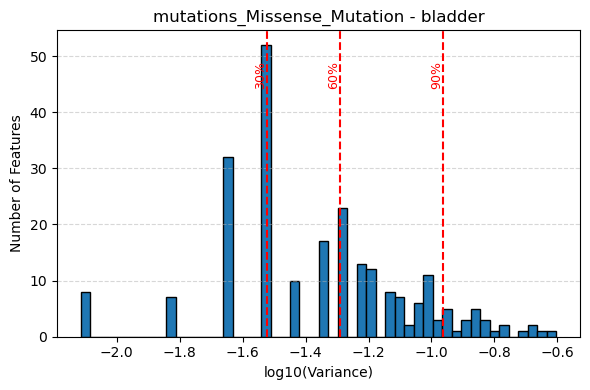

   ⚠️ ccle: Removed 978 non-positive variances before log10 transform


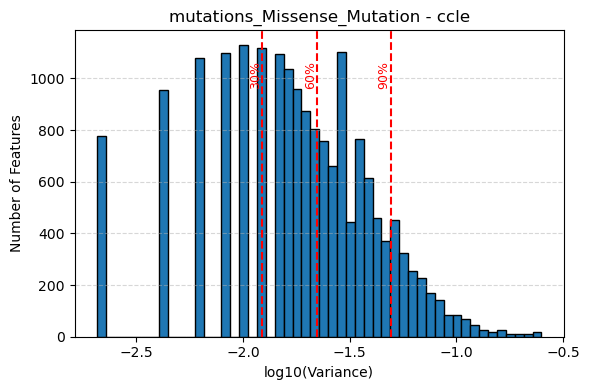

   ⚠️ colorectal: Removed 13737 non-positive variances before log10 transform


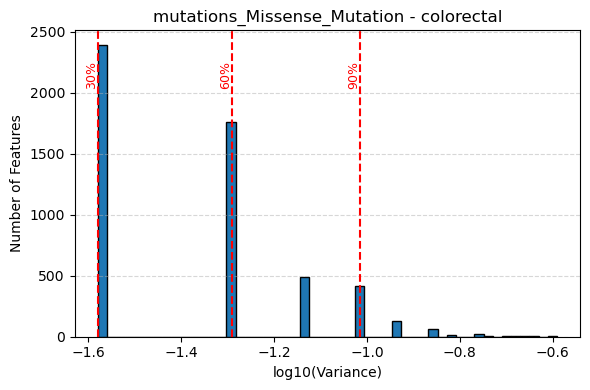

   ⚠️ ctrpv2: Removed 704 non-positive variances before log10 transform


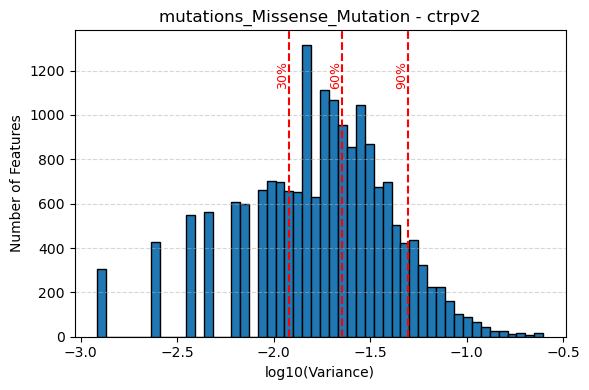

   ⚠️ fimm: Removed 10296 non-positive variances before log10 transform


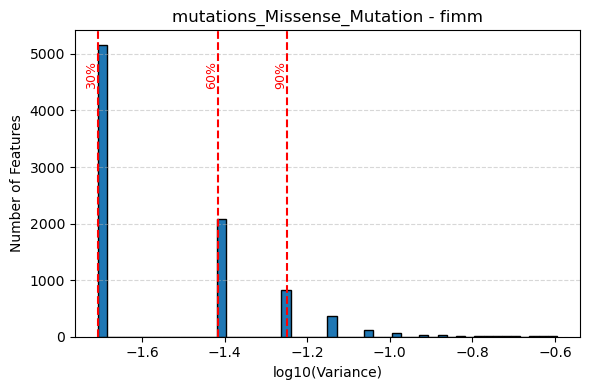

   ⚠️ gcsi: Removed 847 non-positive variances before log10 transform


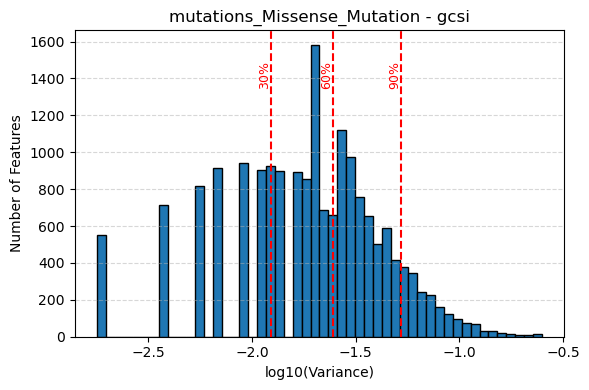

   ⚠️ gdscv1: Removed 671 non-positive variances before log10 transform


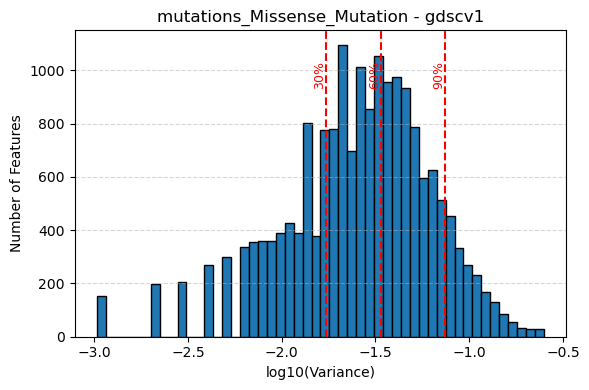

   ⚠️ gdscv2: Removed 696 non-positive variances before log10 transform


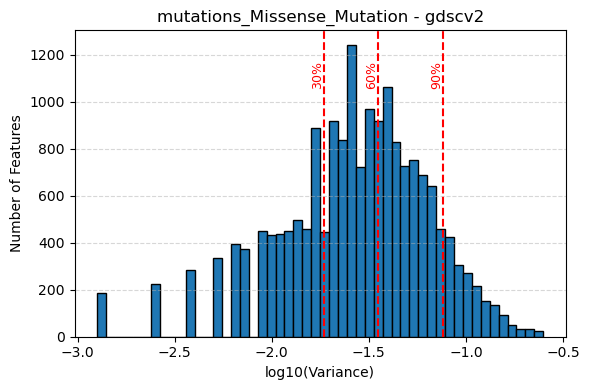

   ⚠️ liver: Removed 14868 non-positive variances before log10 transform


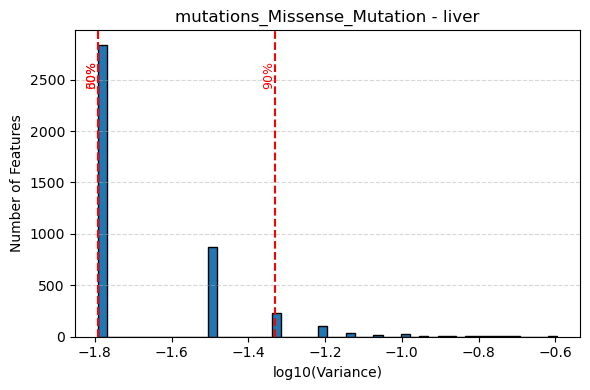

   ⚠️ mpnst: Removed 17647 non-positive variances before log10 transform


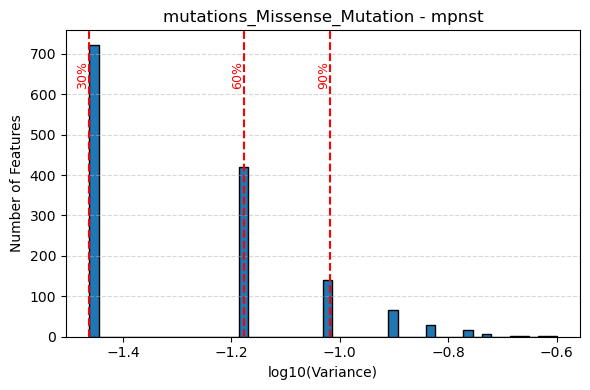

   ⚠️ nci60: Removed 4393 non-positive variances before log10 transform


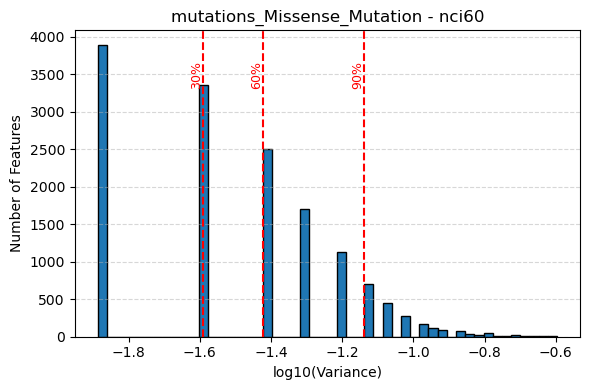

   ⚠️ pancreatic: Removed 8964 non-positive variances before log10 transform


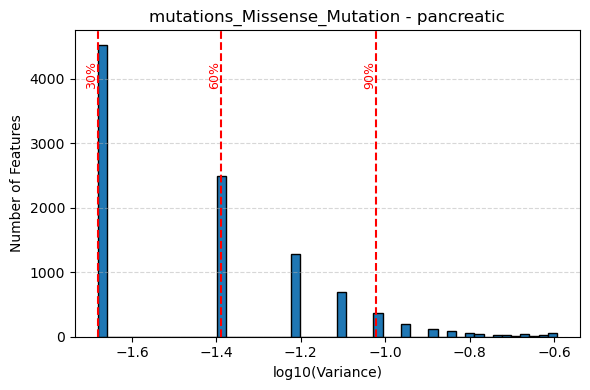

   ⚠️ prism: Removed 922 non-positive variances before log10 transform


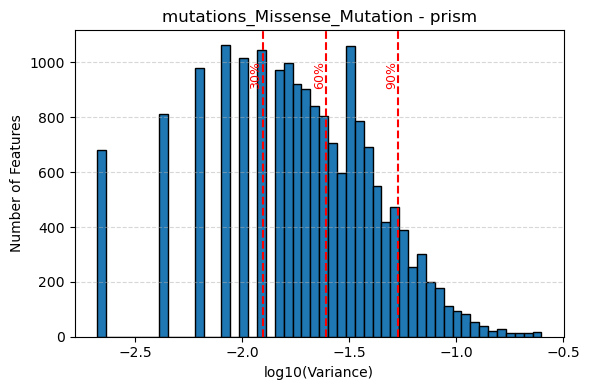

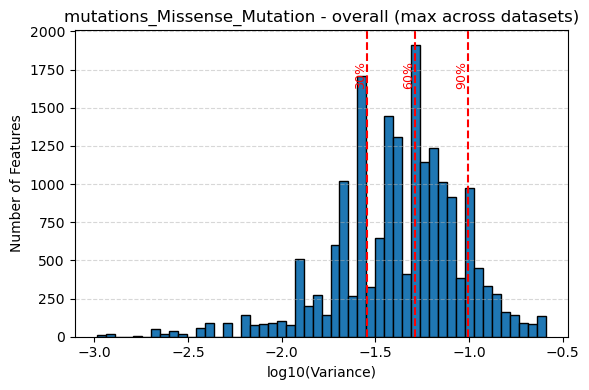

📊 Plotting variance distribution for feature group: mutations_Start_Codon_Ins
   ⚠️ beataml: Removed 419 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Start_Codon_Ins - beataml: no positive variances to plot
   ⚠️ bladder: Removed 419 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Start_Codon_Ins - bladder: no positive variances to plot
   ⚠️ ccle: Removed 412 non-positive variances before log10 transform


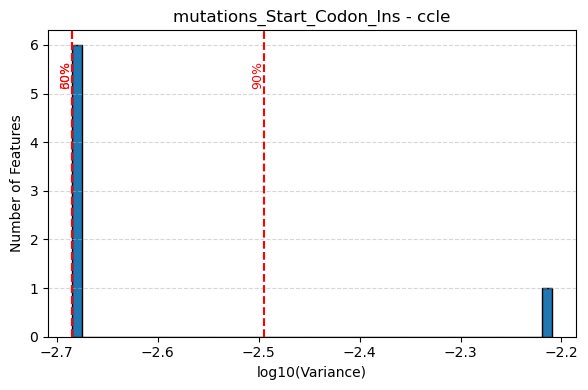

   ⚠️ colorectal: Removed 419 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Start_Codon_Ins - colorectal: no positive variances to plot
   ⚠️ ctrpv2: Removed 409 non-positive variances before log10 transform


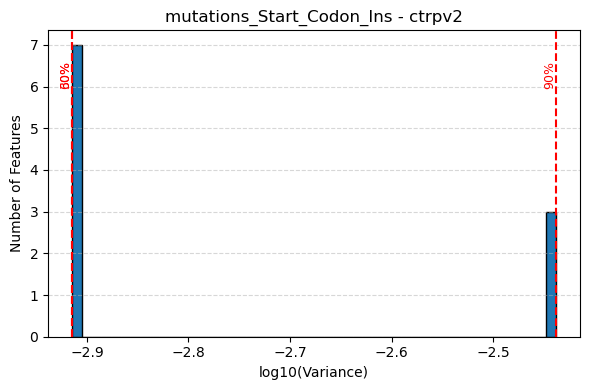

   ⚠️ fimm: Removed 418 non-positive variances before log10 transform


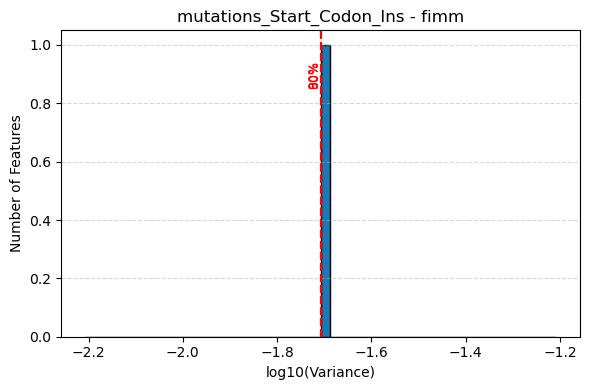

   ⚠️ gcsi: Removed 412 non-positive variances before log10 transform


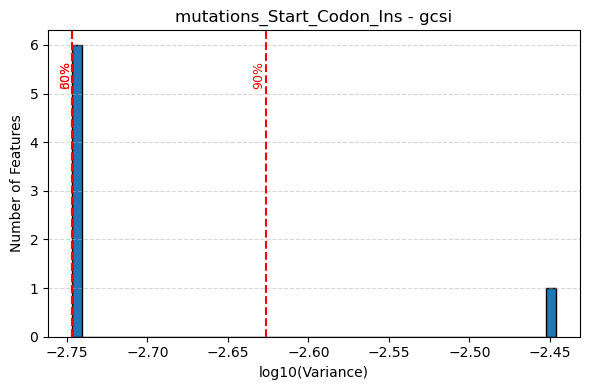

   ⚠️ gdscv1: Removed 419 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Start_Codon_Ins - gdscv1: no positive variances to plot
   ⚠️ gdscv2: Removed 419 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Start_Codon_Ins - gdscv2: no positive variances to plot
   ⚠️ liver: Removed 419 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Start_Codon_Ins - liver: no positive variances to plot
   ⚠️ mpnst: Removed 419 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Start_Codon_Ins - mpnst: no positive variances to plot
   ⚠️ nci60: Removed 418 non-positive variances before log10 transform


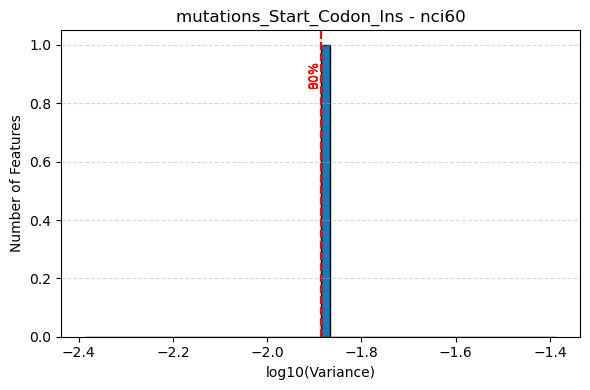

   ⚠️ pancreatic: Removed 12 non-positive variances before log10 transform


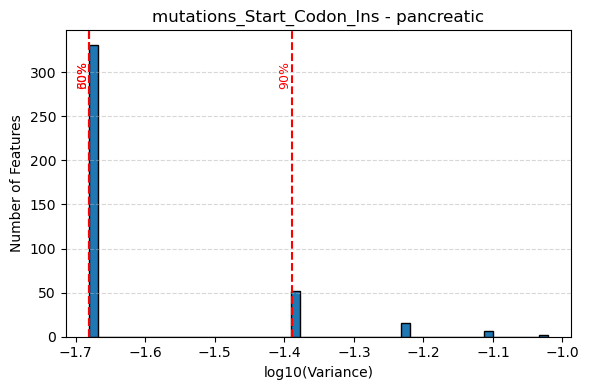

   ⚠️ prism: Removed 410 non-positive variances before log10 transform


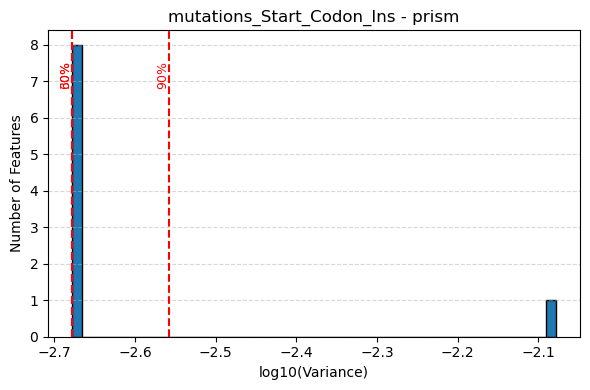

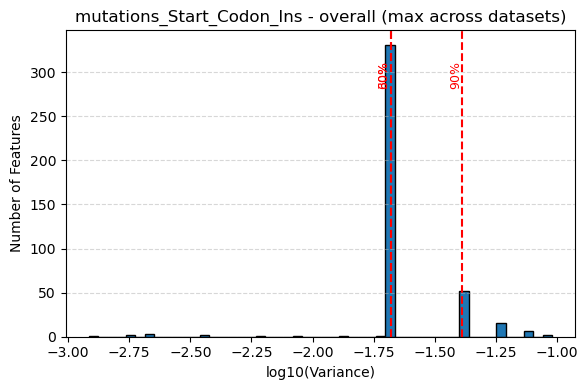

📊 Plotting variance distribution for feature group: mutations_Protein_Altering_Variant


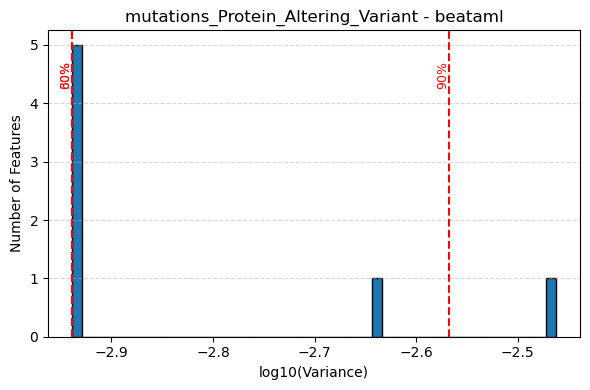

   ⚠️ bladder: Removed 7 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Protein_Altering_Variant - bladder: no positive variances to plot
   ⚠️ ccle: Removed 7 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Protein_Altering_Variant - ccle: no positive variances to plot
   ⚠️ colorectal: Removed 7 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Protein_Altering_Variant - colorectal: no positive variances to plot
   ⚠️ ctrpv2: Removed 7 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Protein_Altering_Variant - ctrpv2: no positive variances to plot
   ⚠️ fimm: Removed 7 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Protein_Altering_Variant - fimm: no positive variances to plot
   ⚠️ gcsi: Removed 7 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Protein_Altering_Variant - gcsi: no positive variances to plot
   ⚠️ gdscv1: Removed 7 non-positive varia

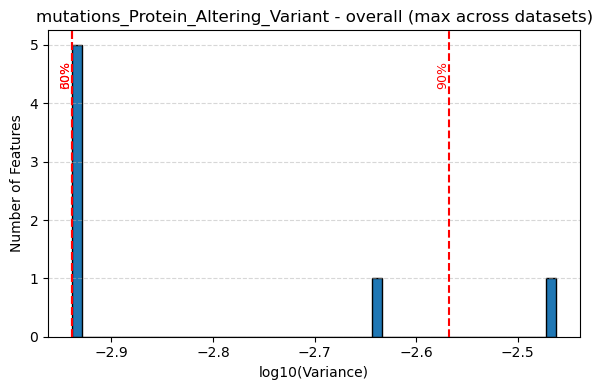

📊 Plotting variance distribution for feature group: mutations_Frameshift_Variant
   ⚠️ beataml: Removed 776 non-positive variances before log10 transform


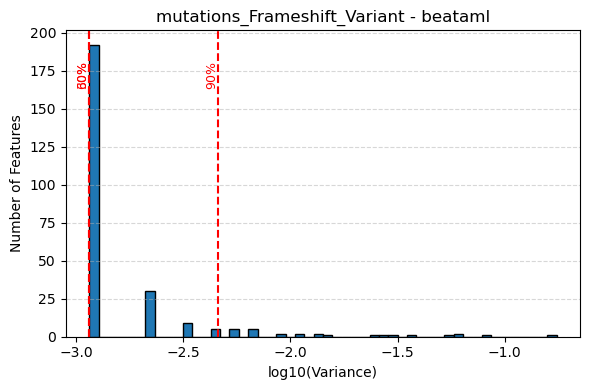

   ⚠️ bladder: Removed 1038 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Frameshift_Variant - bladder: no positive variances to plot
   ⚠️ ccle: Removed 1038 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Frameshift_Variant - ccle: no positive variances to plot
   ⚠️ colorectal: Removed 1038 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Frameshift_Variant - colorectal: no positive variances to plot
   ⚠️ ctrpv2: Removed 1038 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Frameshift_Variant - ctrpv2: no positive variances to plot
   ⚠️ fimm: Removed 1038 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Frameshift_Variant - fimm: no positive variances to plot
   ⚠️ gcsi: Removed 1038 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Frameshift_Variant - gcsi: no positive variances to plot
   ⚠️ gdscv1: Removed 1038 non-positive variances before log

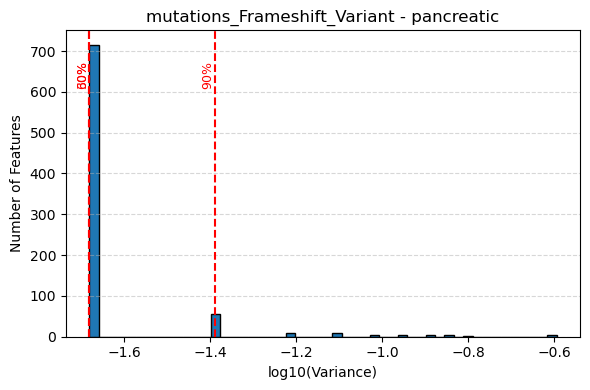

   ⚠️ prism: Removed 1038 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Frameshift_Variant - prism: no positive variances to plot


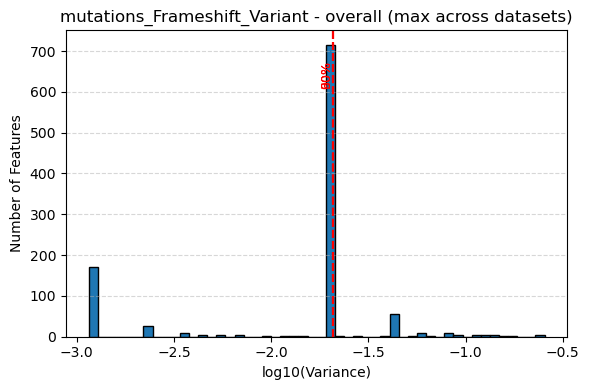

📊 Plotting variance distribution for feature group: mutations_In_Frame_Del
   ⚠️ beataml: Removed 5167 non-positive variances before log10 transform


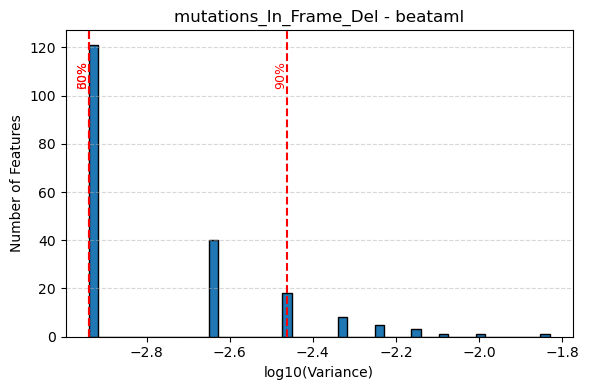

   ⚠️ bladder: Removed 5338 non-positive variances before log10 transform


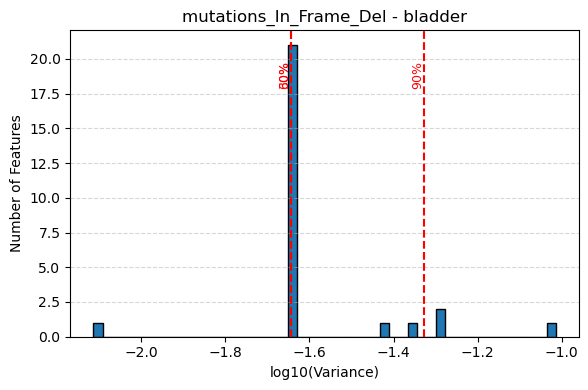

   ⚠️ ccle: Removed 4165 non-positive variances before log10 transform


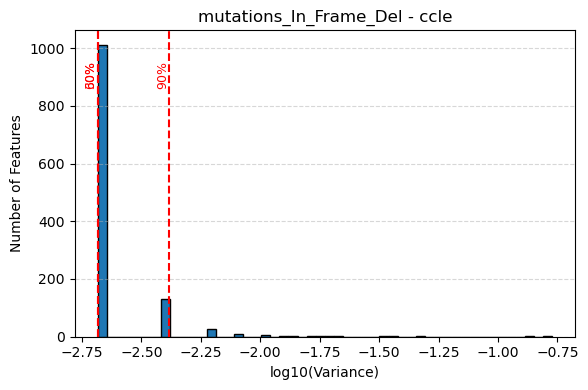

   ⚠️ colorectal: Removed 5209 non-positive variances before log10 transform


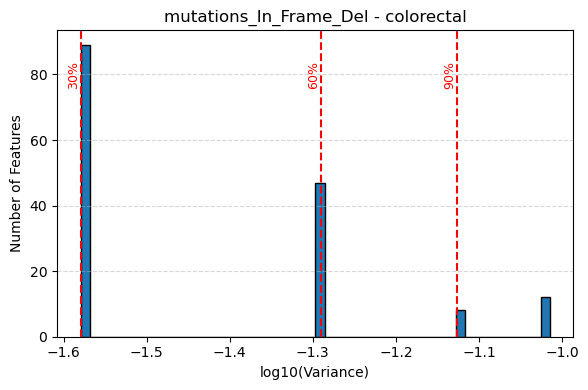

   ⚠️ ctrpv2: Removed 3577 non-positive variances before log10 transform


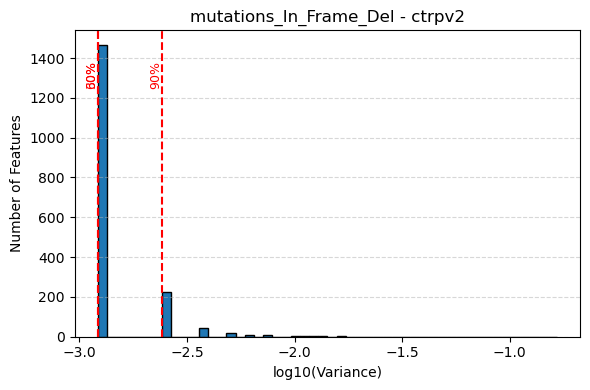

   ⚠️ fimm: Removed 5252 non-positive variances before log10 transform


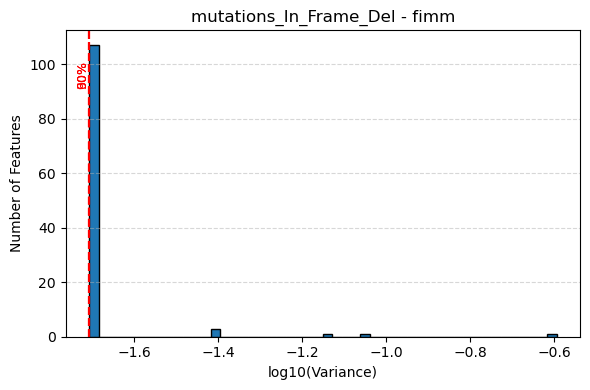

   ⚠️ gcsi: Removed 4005 non-positive variances before log10 transform


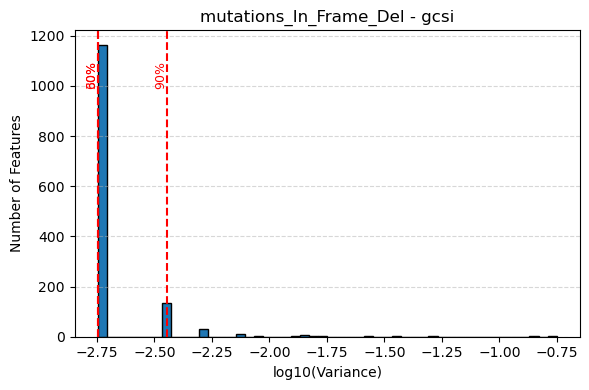

   ⚠️ gdscv1: Removed 924 non-positive variances before log10 transform


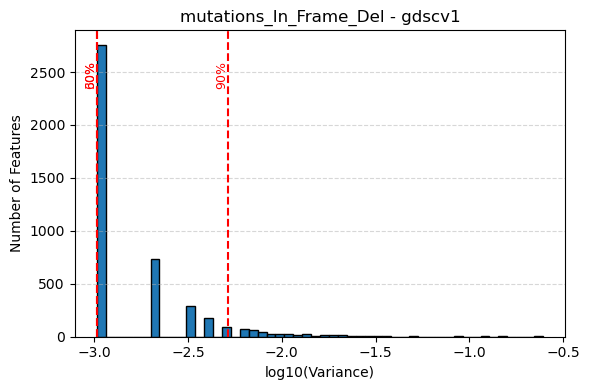

   ⚠️ gdscv2: Removed 1298 non-positive variances before log10 transform


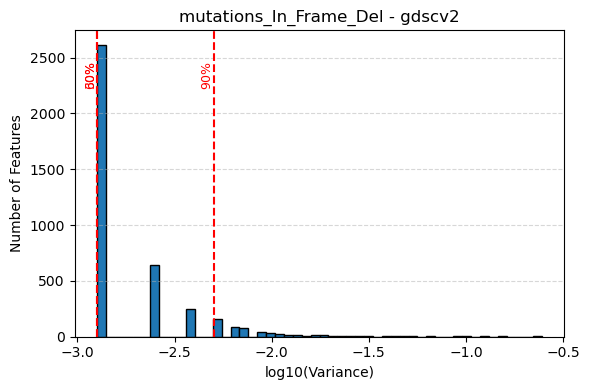

   ⚠️ liver: Removed 5219 non-positive variances before log10 transform


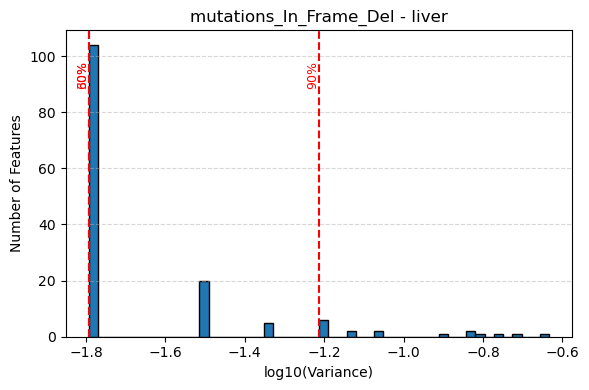

   ⚠️ mpnst: Removed 5252 non-positive variances before log10 transform


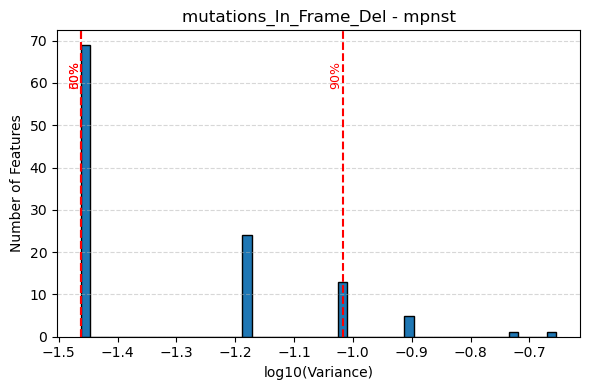

   ⚠️ nci60: Removed 5166 non-positive variances before log10 transform


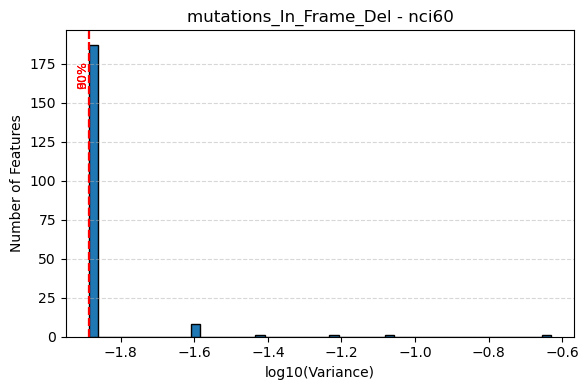

   ⚠️ pancreatic: Removed 4995 non-positive variances before log10 transform


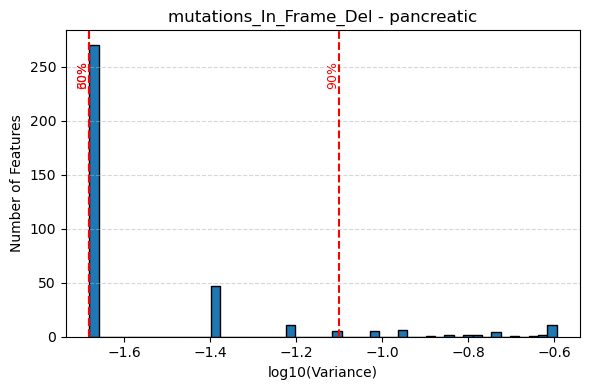

   ⚠️ prism: Removed 4076 non-positive variances before log10 transform


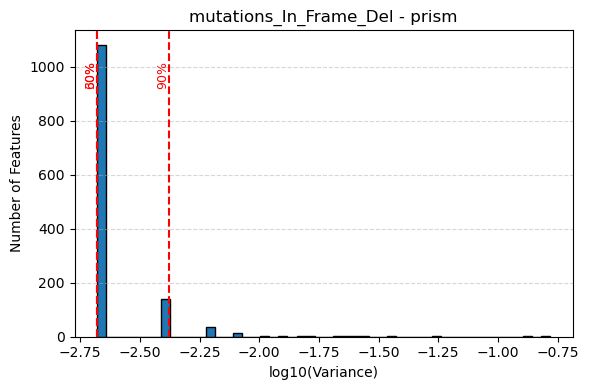

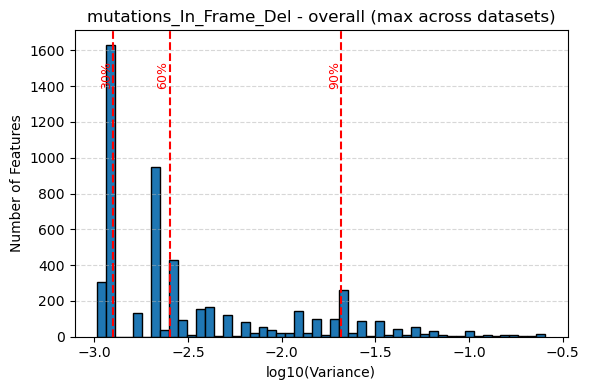

📊 Plotting variance distribution for feature group: mutations_Splice_Region
   ⚠️ beataml: Removed 436 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Splice_Region - beataml: no positive variances to plot
   ⚠️ bladder: Removed 435 non-positive variances before log10 transform


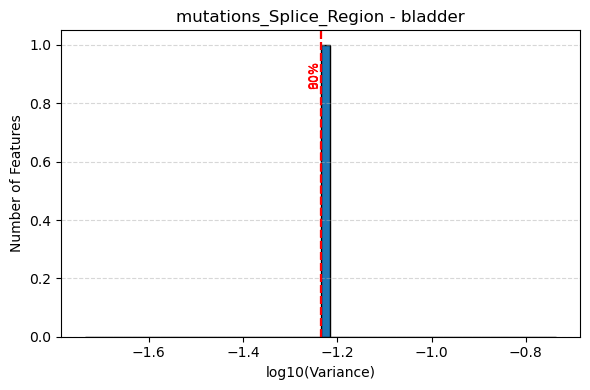

   ⚠️ ccle: Removed 436 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Splice_Region - ccle: no positive variances to plot
   ⚠️ colorectal: Removed 436 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Splice_Region - colorectal: no positive variances to plot
   ⚠️ ctrpv2: Removed 436 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Splice_Region - ctrpv2: no positive variances to plot
   ⚠️ fimm: Removed 436 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Splice_Region - fimm: no positive variances to plot
   ⚠️ gcsi: Removed 436 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Splice_Region - gcsi: no positive variances to plot
   ⚠️ gdscv1: Removed 436 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Splice_Region - gdscv1: no positive variances to plot
   ⚠️ gdscv2: Removed 436 non-positive variances before log10 transform
   ⚠️ Skipping mutations_S

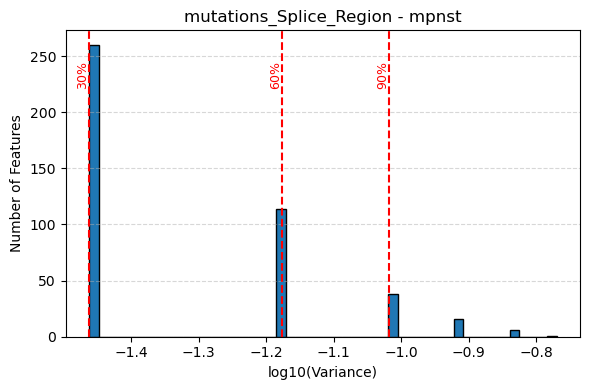

   ⚠️ nci60: Removed 436 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Splice_Region - nci60: no positive variances to plot
   ⚠️ pancreatic: Removed 436 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Splice_Region - pancreatic: no positive variances to plot
   ⚠️ prism: Removed 436 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Splice_Region - prism: no positive variances to plot


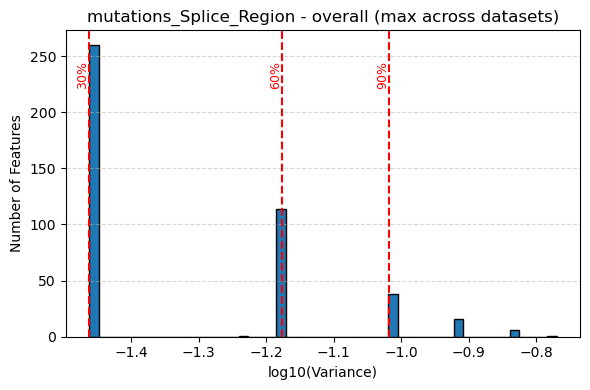

📊 Plotting variance distribution for feature group: mutations_Nonsense_Mutation
   ⚠️ beataml: Removed 13318 non-positive variances before log10 transform


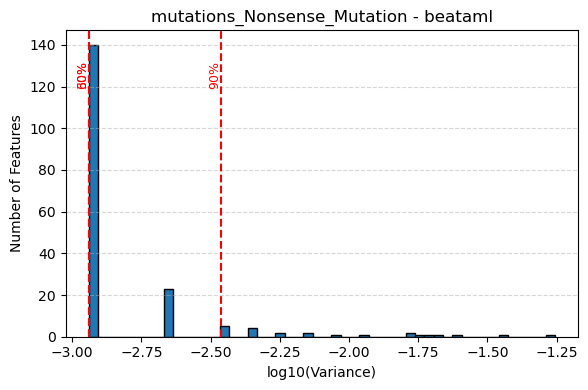

   ⚠️ bladder: Removed 13467 non-positive variances before log10 transform


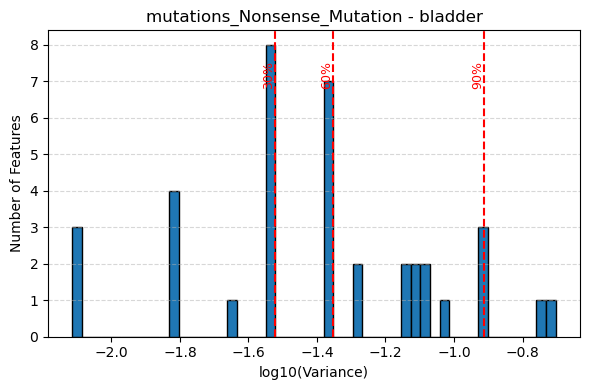

   ⚠️ ccle: Removed 5879 non-positive variances before log10 transform


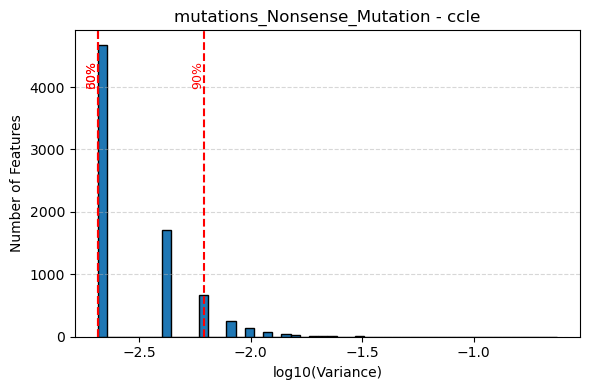

   ⚠️ colorectal: Removed 13100 non-positive variances before log10 transform


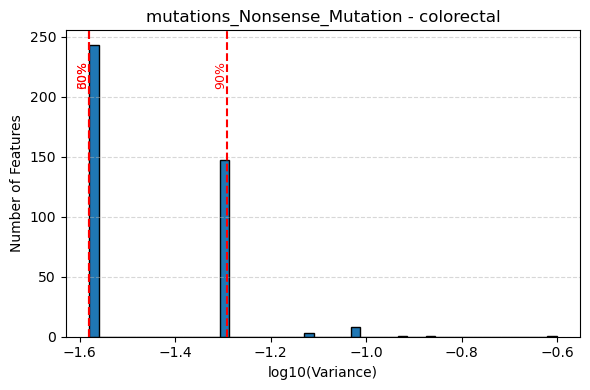

   ⚠️ ctrpv2: Removed 3008 non-positive variances before log10 transform


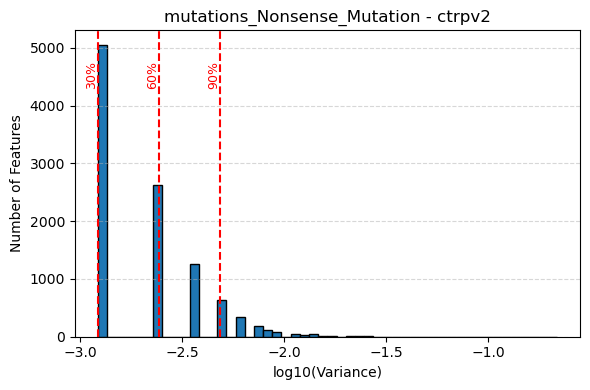

   ⚠️ fimm: Removed 12739 non-positive variances before log10 transform


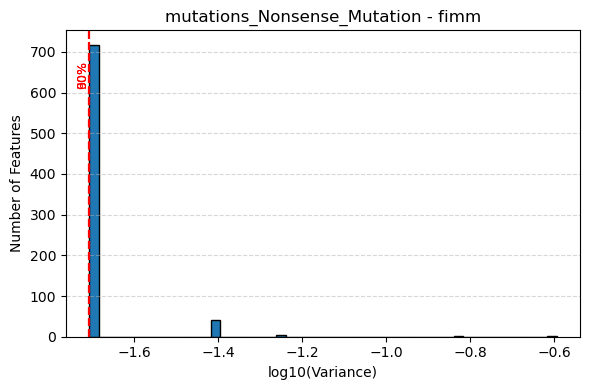

   ⚠️ gcsi: Removed 4867 non-positive variances before log10 transform


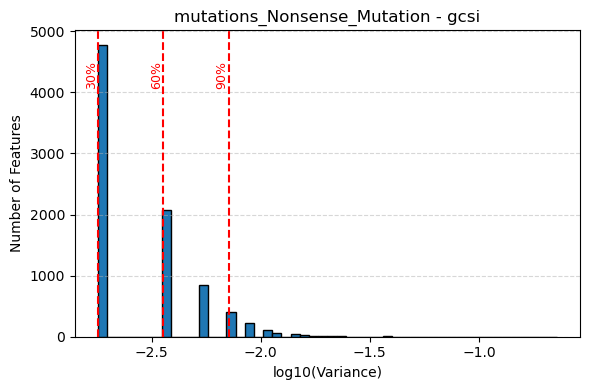

   ⚠️ gdscv1: Removed 1879 non-positive variances before log10 transform


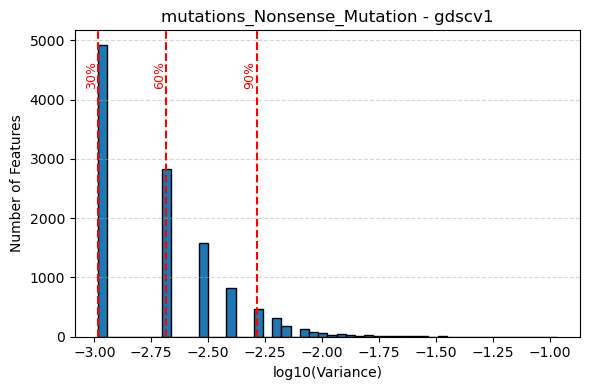

   ⚠️ gdscv2: Removed 2505 non-positive variances before log10 transform


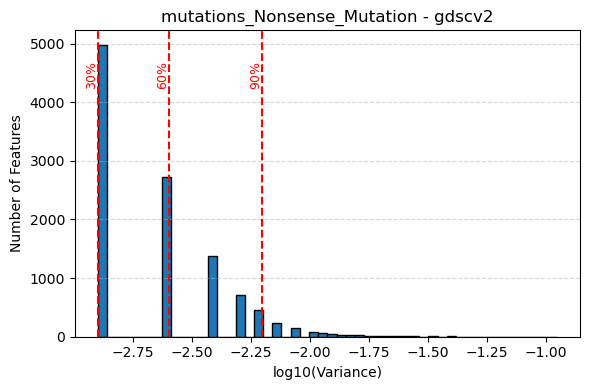

   ⚠️ liver: Removed 13182 non-positive variances before log10 transform


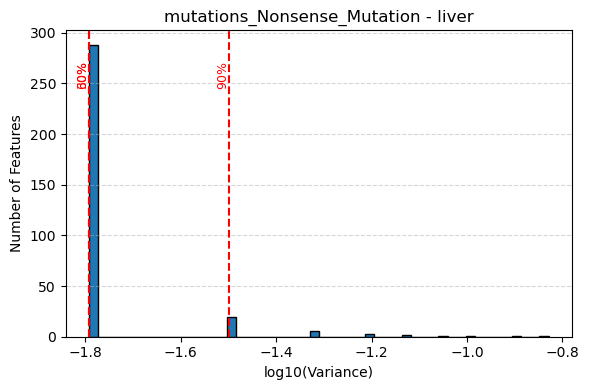

   ⚠️ mpnst: Removed 13460 non-positive variances before log10 transform


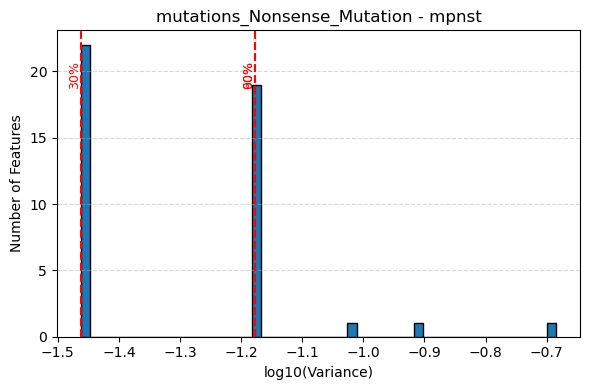

   ⚠️ nci60: Removed 10827 non-positive variances before log10 transform


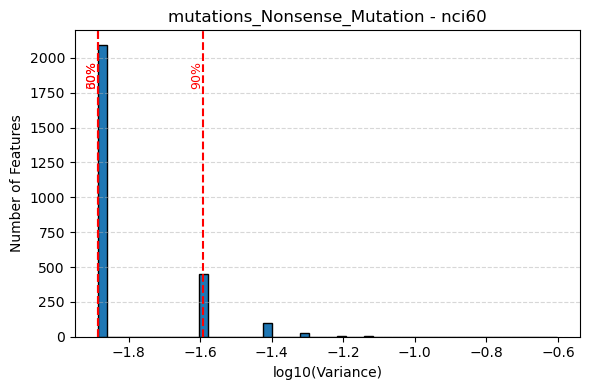

   ⚠️ pancreatic: Removed 13504 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Nonsense_Mutation - pancreatic: no positive variances to plot
   ⚠️ prism: Removed 5292 non-positive variances before log10 transform


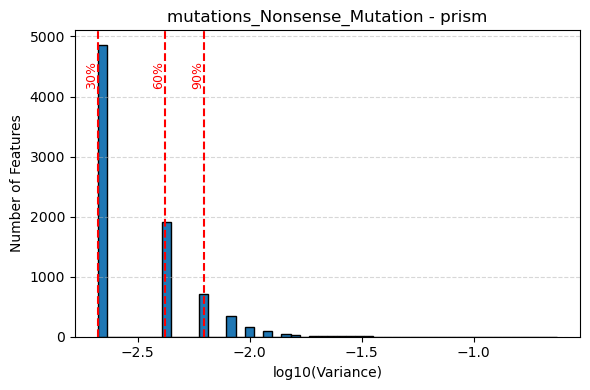

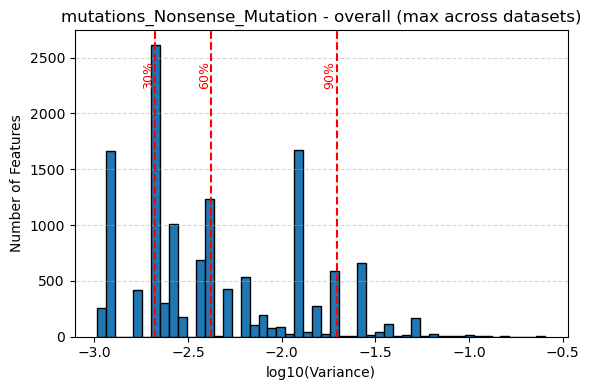

📊 Plotting variance distribution for feature group: mutations_Stop_Codon_Ins
   ⚠️ beataml: Removed 517 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Stop_Codon_Ins - beataml: no positive variances to plot
   ⚠️ bladder: Removed 517 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Stop_Codon_Ins - bladder: no positive variances to plot
   ⚠️ ccle: Removed 517 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Stop_Codon_Ins - ccle: no positive variances to plot
   ⚠️ colorectal: Removed 516 non-positive variances before log10 transform


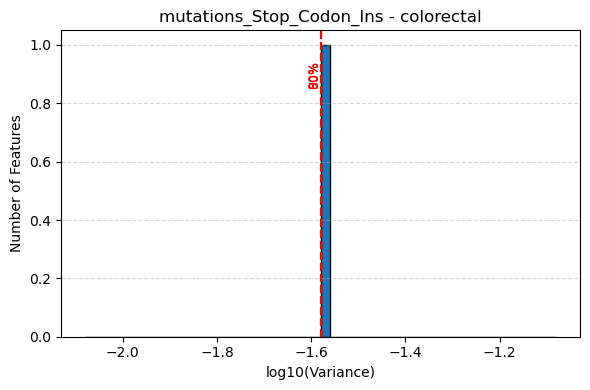

   ⚠️ ctrpv2: Removed 517 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Stop_Codon_Ins - ctrpv2: no positive variances to plot
   ⚠️ fimm: Removed 517 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Stop_Codon_Ins - fimm: no positive variances to plot
   ⚠️ gcsi: Removed 517 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Stop_Codon_Ins - gcsi: no positive variances to plot
   ⚠️ gdscv1: Removed 517 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Stop_Codon_Ins - gdscv1: no positive variances to plot
   ⚠️ gdscv2: Removed 517 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Stop_Codon_Ins - gdscv2: no positive variances to plot
   ⚠️ liver: Removed 517 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Stop_Codon_Ins - liver: no positive variances to plot
   ⚠️ mpnst: Removed 517 non-positive variances before log10 transform
   ⚠️ Skipping mutations_St

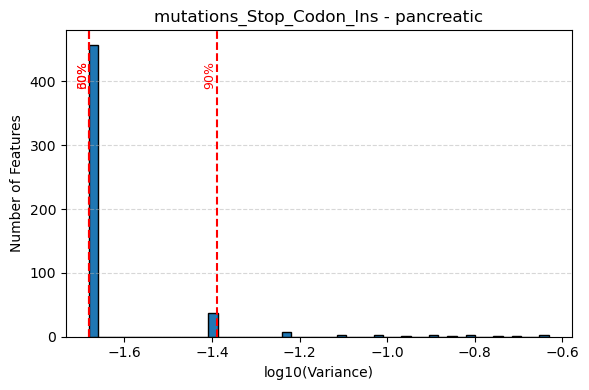

   ⚠️ prism: Removed 517 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Stop_Codon_Ins - prism: no positive variances to plot


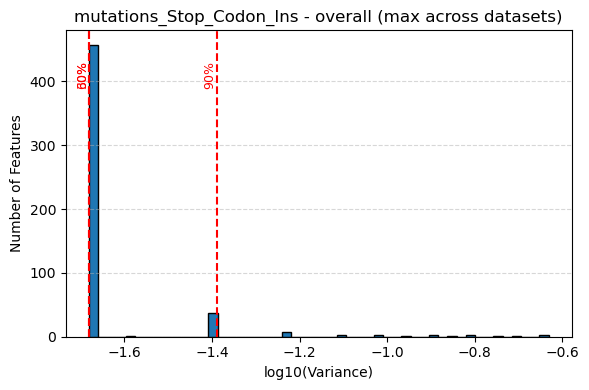

📊 Plotting variance distribution for feature group: mutations_Splice_Site
   ⚠️ beataml: Removed 15192 non-positive variances before log10 transform


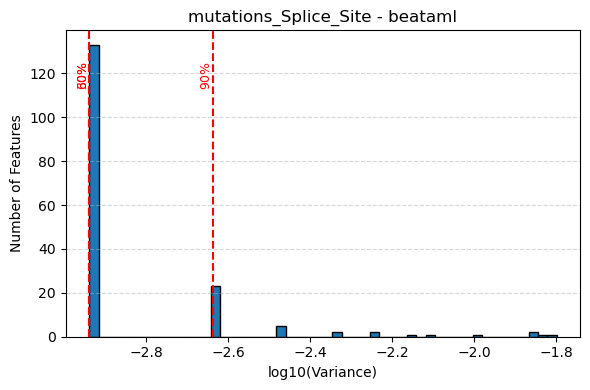

   ⚠️ bladder: Removed 15357 non-positive variances before log10 transform


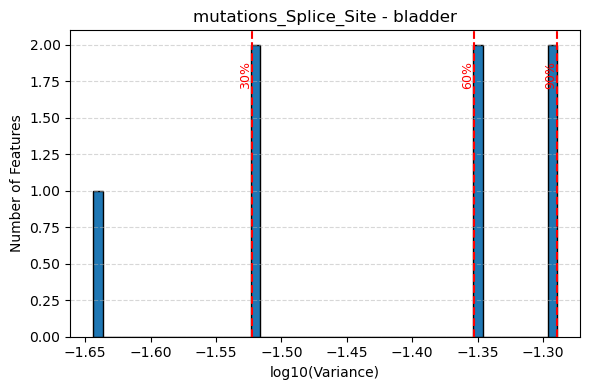

   ⚠️ ccle: Removed 7692 non-positive variances before log10 transform


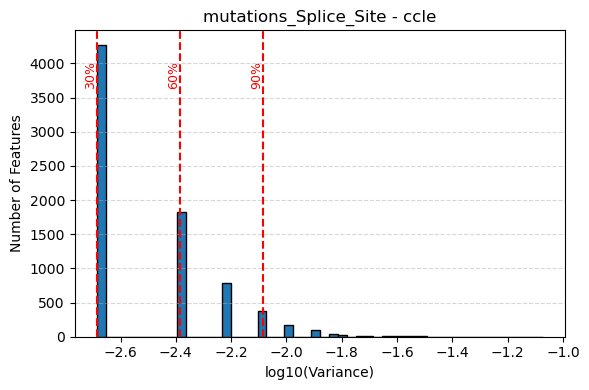

   ⚠️ colorectal: Removed 14930 non-positive variances before log10 transform


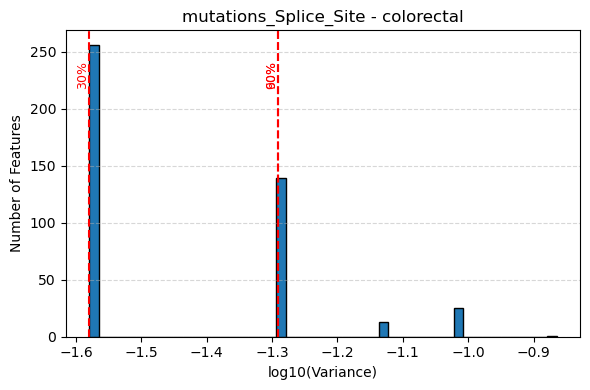

   ⚠️ ctrpv2: Removed 5271 non-positive variances before log10 transform


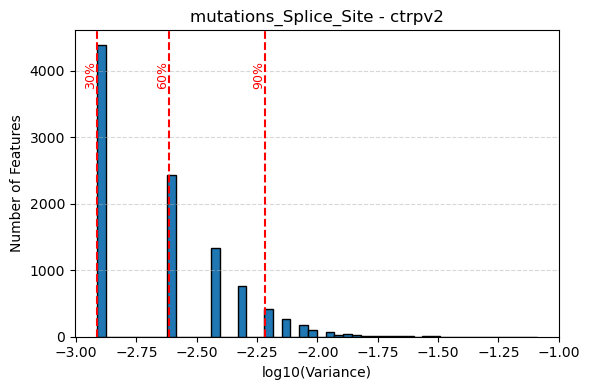

   ⚠️ fimm: Removed 14582 non-positive variances before log10 transform


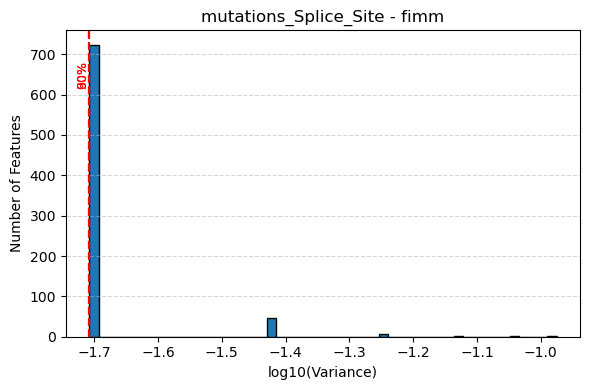

   ⚠️ gcsi: Removed 6939 non-positive variances before log10 transform


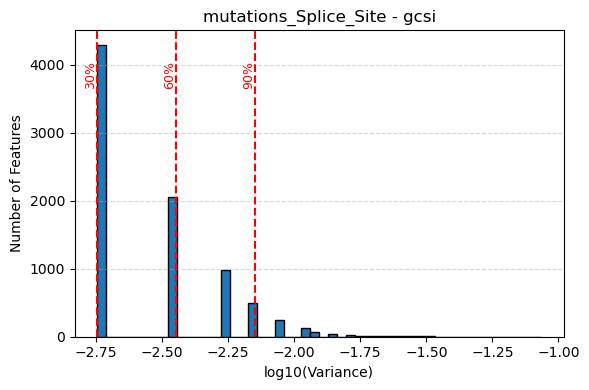

   ⚠️ gdscv1: Removed 1310 non-positive variances before log10 transform


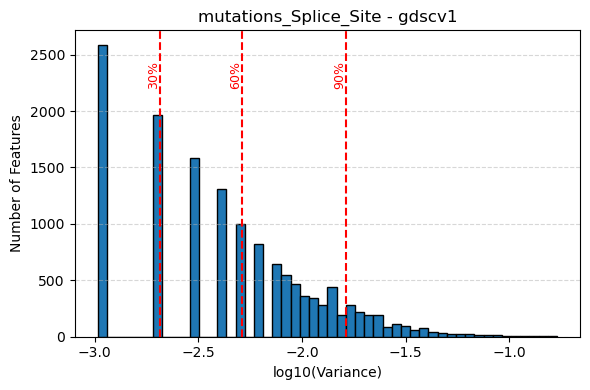

   ⚠️ gdscv2: Removed 1670 non-positive variances before log10 transform


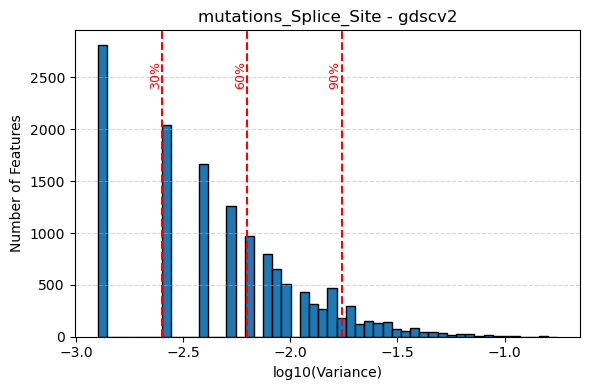

   ⚠️ liver: Removed 15188 non-positive variances before log10 transform


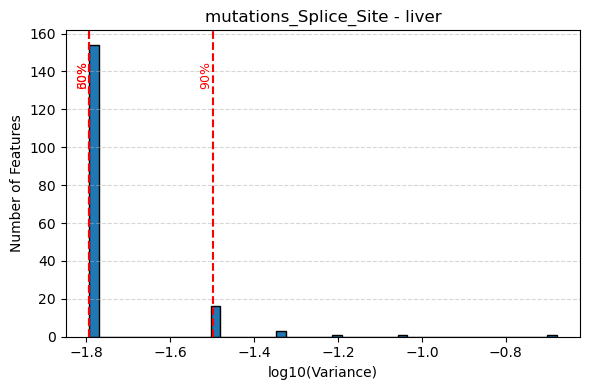

   ⚠️ mpnst: Removed 15329 non-positive variances before log10 transform


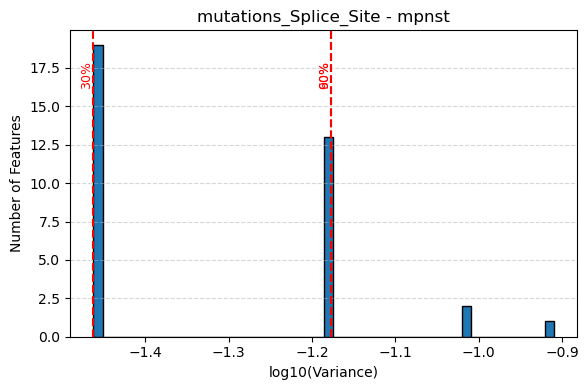

   ⚠️ nci60: Removed 12830 non-positive variances before log10 transform


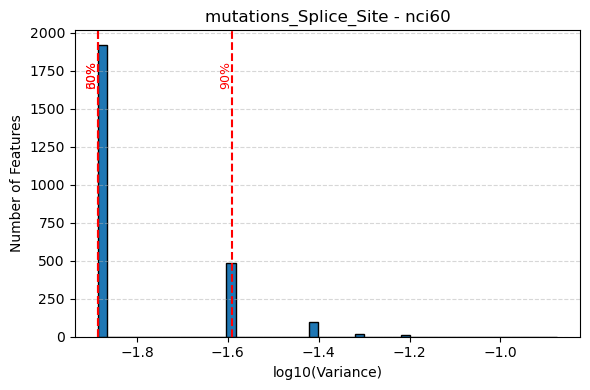

   ⚠️ pancreatic: Removed 13256 non-positive variances before log10 transform


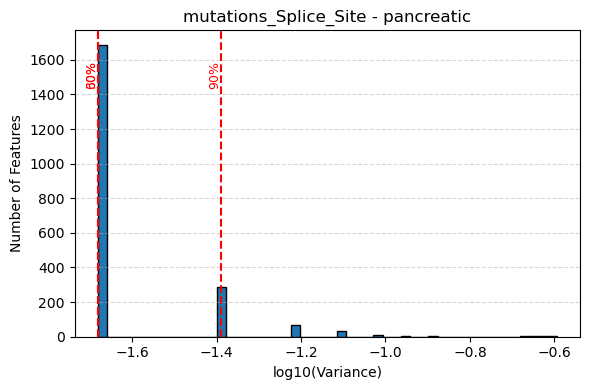

   ⚠️ prism: Removed 7219 non-positive variances before log10 transform


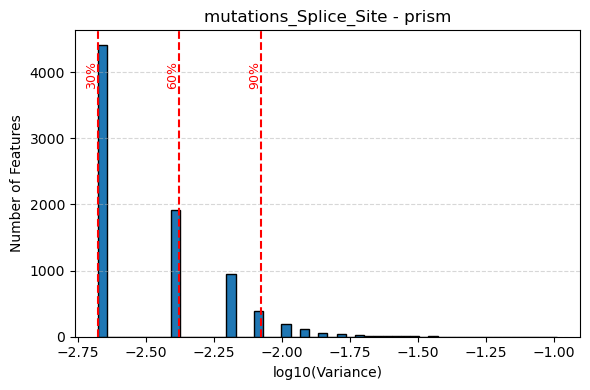

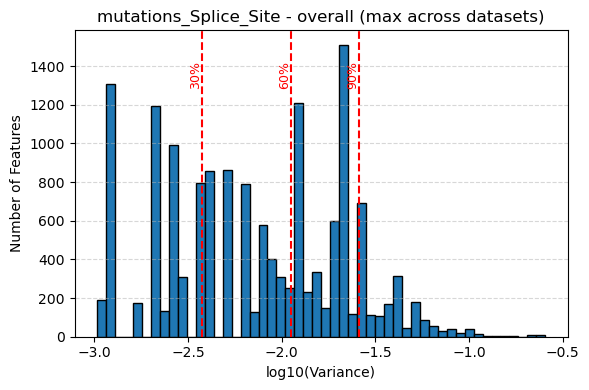

📊 Plotting variance distribution for feature group: mutations_3'UTR
   ⚠️ beataml: Removed 17052 non-positive variances before log10 transform
   ⚠️ Skipping mutations_3'UTR - beataml: no positive variances to plot
   ⚠️ bladder: Removed 17052 non-positive variances before log10 transform
   ⚠️ Skipping mutations_3'UTR - bladder: no positive variances to plot
   ⚠️ ccle: Removed 17052 non-positive variances before log10 transform
   ⚠️ Skipping mutations_3'UTR - ccle: no positive variances to plot
   ⚠️ colorectal: Removed 15370 non-positive variances before log10 transform


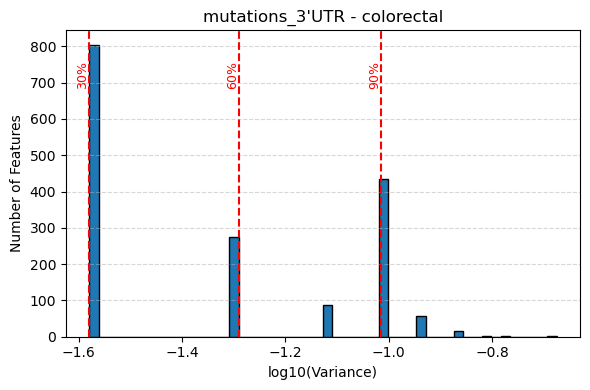

   ⚠️ ctrpv2: Removed 17052 non-positive variances before log10 transform
   ⚠️ Skipping mutations_3'UTR - ctrpv2: no positive variances to plot
   ⚠️ fimm: Removed 17052 non-positive variances before log10 transform
   ⚠️ Skipping mutations_3'UTR - fimm: no positive variances to plot
   ⚠️ gcsi: Removed 17052 non-positive variances before log10 transform
   ⚠️ Skipping mutations_3'UTR - gcsi: no positive variances to plot
   ⚠️ gdscv1: Removed 243 non-positive variances before log10 transform


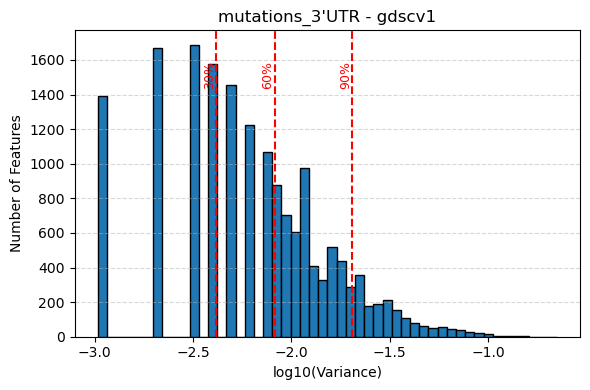

   ⚠️ gdscv2: Removed 417 non-positive variances before log10 transform


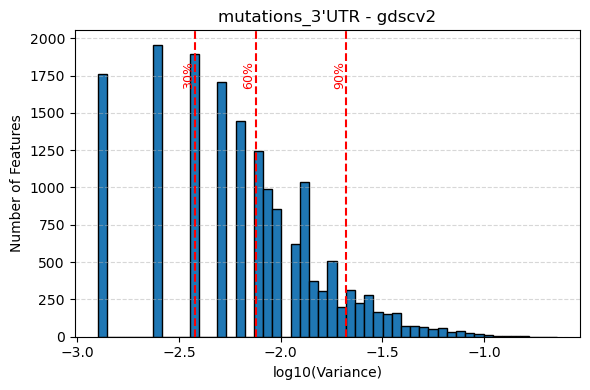

   ⚠️ liver: Removed 17052 non-positive variances before log10 transform
   ⚠️ Skipping mutations_3'UTR - liver: no positive variances to plot
   ⚠️ mpnst: Removed 15766 non-positive variances before log10 transform


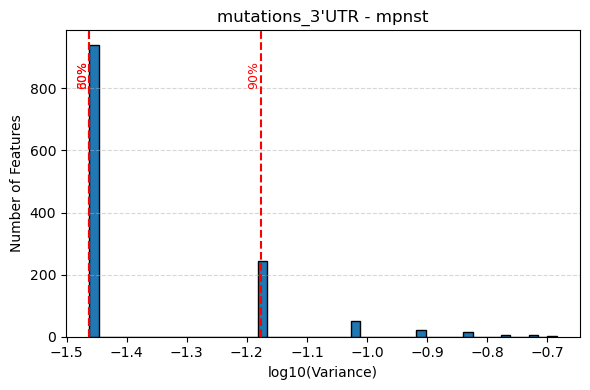

   ⚠️ nci60: Removed 17052 non-positive variances before log10 transform
   ⚠️ Skipping mutations_3'UTR - nci60: no positive variances to plot
   ⚠️ pancreatic: Removed 15060 non-positive variances before log10 transform


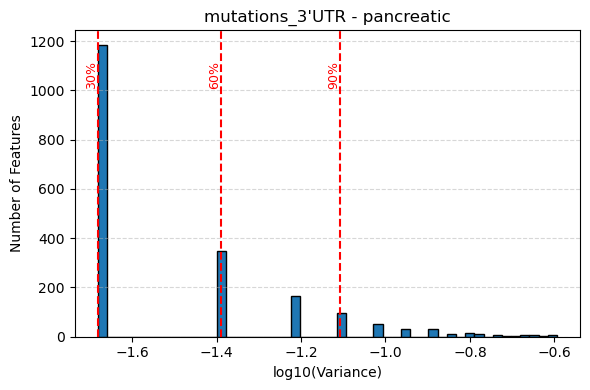

   ⚠️ prism: Removed 17052 non-positive variances before log10 transform
   ⚠️ Skipping mutations_3'UTR - prism: no positive variances to plot


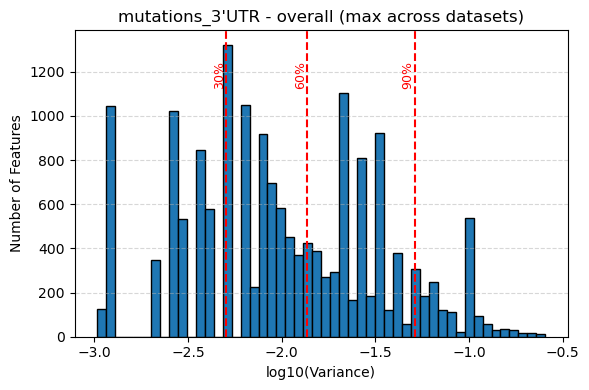

📊 Plotting variance distribution for feature group: mutations_RNA
   ⚠️ beataml: Removed 148 non-positive variances before log10 transform
   ⚠️ Skipping mutations_RNA - beataml: no positive variances to plot
   ⚠️ bladder: Removed 148 non-positive variances before log10 transform
   ⚠️ Skipping mutations_RNA - bladder: no positive variances to plot
   ⚠️ ccle: Removed 148 non-positive variances before log10 transform
   ⚠️ Skipping mutations_RNA - ccle: no positive variances to plot


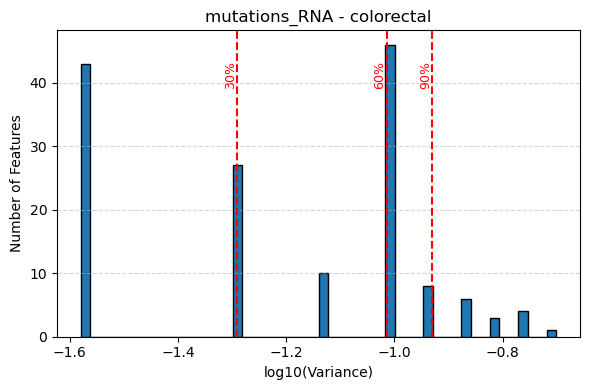

   ⚠️ ctrpv2: Removed 148 non-positive variances before log10 transform
   ⚠️ Skipping mutations_RNA - ctrpv2: no positive variances to plot
   ⚠️ fimm: Removed 148 non-positive variances before log10 transform
   ⚠️ Skipping mutations_RNA - fimm: no positive variances to plot
   ⚠️ gcsi: Removed 148 non-positive variances before log10 transform
   ⚠️ Skipping mutations_RNA - gcsi: no positive variances to plot
   ⚠️ gdscv1: Removed 148 non-positive variances before log10 transform
   ⚠️ Skipping mutations_RNA - gdscv1: no positive variances to plot
   ⚠️ gdscv2: Removed 148 non-positive variances before log10 transform
   ⚠️ Skipping mutations_RNA - gdscv2: no positive variances to plot
   ⚠️ liver: Removed 148 non-positive variances before log10 transform
   ⚠️ Skipping mutations_RNA - liver: no positive variances to plot
   ⚠️ mpnst: Removed 148 non-positive variances before log10 transform
   ⚠️ Skipping mutations_RNA - mpnst: no positive variances to plot
   ⚠️ nci60: Removed 148 

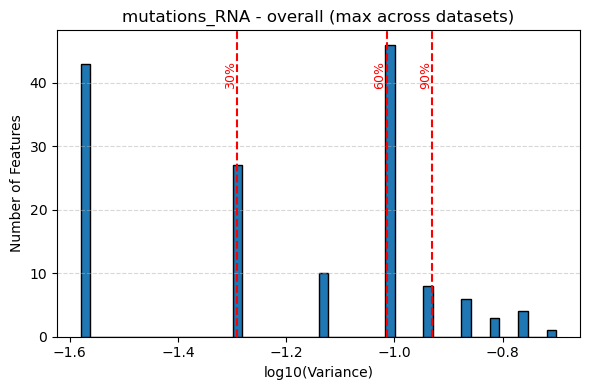

📊 Plotting variance distribution for feature group: mutations_Stop_Codon_Del
   ⚠️ beataml: Removed 574 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Stop_Codon_Del - beataml: no positive variances to plot
   ⚠️ bladder: Removed 574 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Stop_Codon_Del - bladder: no positive variances to plot
   ⚠️ ccle: Removed 574 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Stop_Codon_Del - ccle: no positive variances to plot
   ⚠️ colorectal: Removed 572 non-positive variances before log10 transform


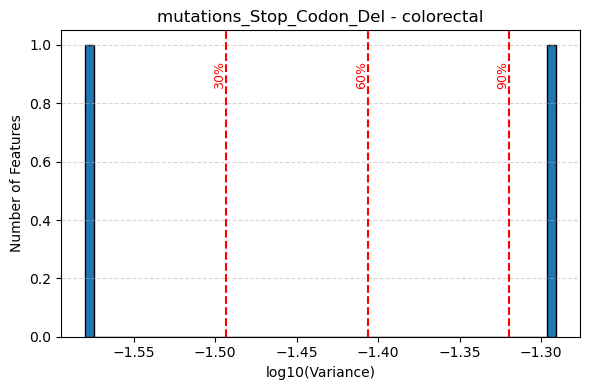

   ⚠️ ctrpv2: Removed 574 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Stop_Codon_Del - ctrpv2: no positive variances to plot
   ⚠️ fimm: Removed 574 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Stop_Codon_Del - fimm: no positive variances to plot
   ⚠️ gcsi: Removed 574 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Stop_Codon_Del - gcsi: no positive variances to plot
   ⚠️ gdscv1: Removed 3 non-positive variances before log10 transform


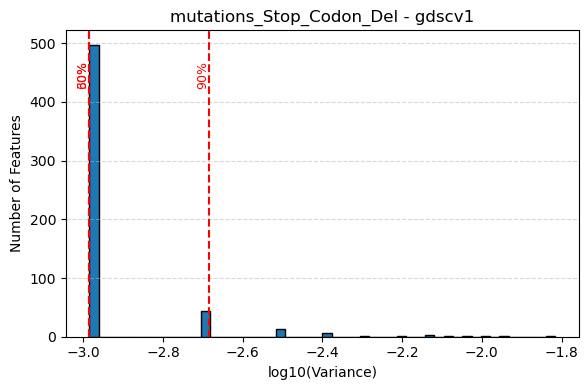

   ⚠️ gdscv2: Removed 61 non-positive variances before log10 transform


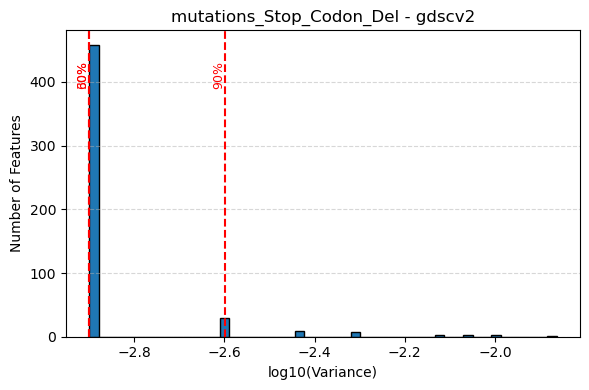

   ⚠️ liver: Removed 574 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Stop_Codon_Del - liver: no positive variances to plot
   ⚠️ mpnst: Removed 574 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Stop_Codon_Del - mpnst: no positive variances to plot
   ⚠️ nci60: Removed 574 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Stop_Codon_Del - nci60: no positive variances to plot
   ⚠️ pancreatic: Removed 574 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Stop_Codon_Del - pancreatic: no positive variances to plot
   ⚠️ prism: Removed 574 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Stop_Codon_Del - prism: no positive variances to plot


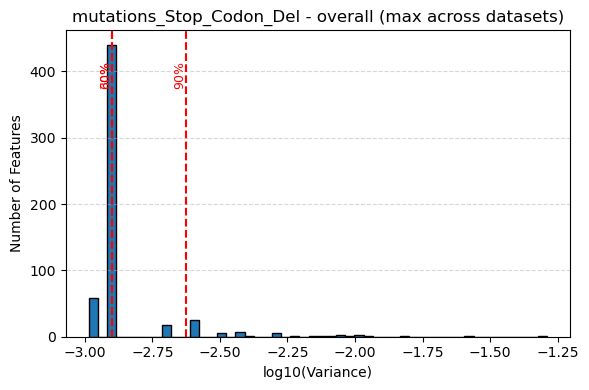

📊 Plotting variance distribution for feature group: mutations_Start_Codon_Del
   ⚠️ beataml: Removed 898 non-positive variances before log10 transform


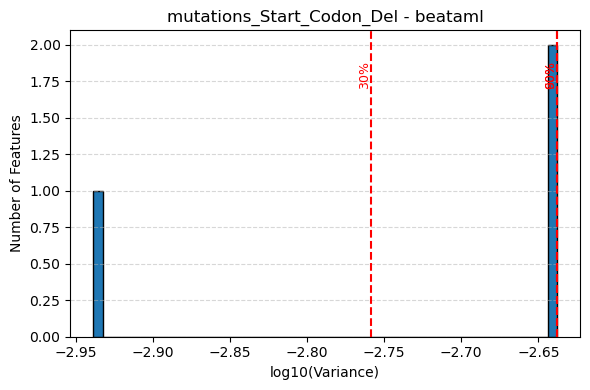

   ⚠️ bladder: Removed 901 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Start_Codon_Del - bladder: no positive variances to plot
   ⚠️ ccle: Removed 901 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Start_Codon_Del - ccle: no positive variances to plot
   ⚠️ colorectal: Removed 901 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Start_Codon_Del - colorectal: no positive variances to plot
   ⚠️ ctrpv2: Removed 901 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Start_Codon_Del - ctrpv2: no positive variances to plot
   ⚠️ fimm: Removed 901 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Start_Codon_Del - fimm: no positive variances to plot
   ⚠️ gcsi: Removed 901 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Start_Codon_Del - gcsi: no positive variances to plot
   ⚠️ gdscv1: Removed 3 non-positive variances before log10 transform


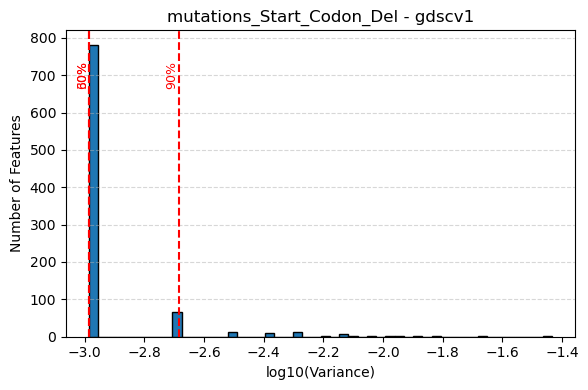

   ⚠️ gdscv2: Removed 128 non-positive variances before log10 transform


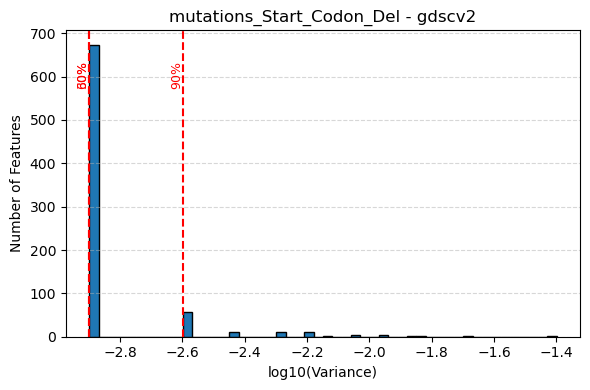

   ⚠️ liver: Removed 901 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Start_Codon_Del - liver: no positive variances to plot
   ⚠️ mpnst: Removed 901 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Start_Codon_Del - mpnst: no positive variances to plot
   ⚠️ nci60: Removed 901 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Start_Codon_Del - nci60: no positive variances to plot
   ⚠️ pancreatic: Removed 901 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Start_Codon_Del - pancreatic: no positive variances to plot
   ⚠️ prism: Removed 901 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Start_Codon_Del - prism: no positive variances to plot


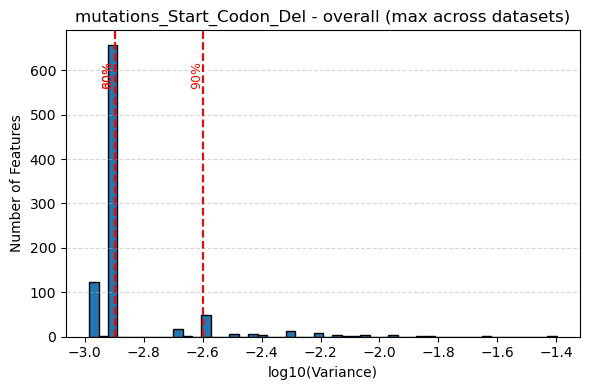

📊 Plotting variance distribution for feature group: mutations_Nonstop_Mutation
   ⚠️ beataml: Removed 642 non-positive variances before log10 transform


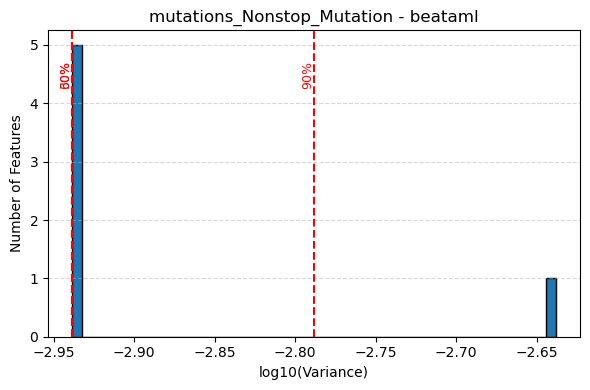

   ⚠️ bladder: Removed 647 non-positive variances before log10 transform


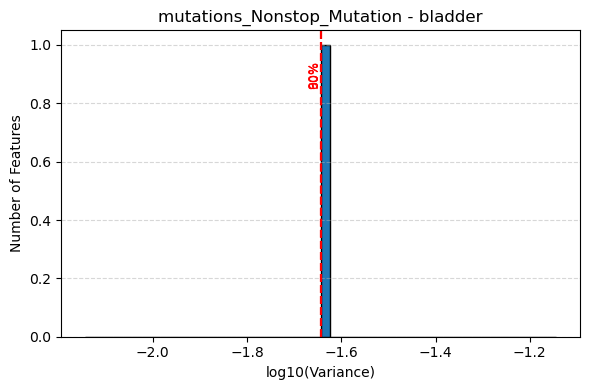

   ⚠️ ccle: Removed 332 non-positive variances before log10 transform


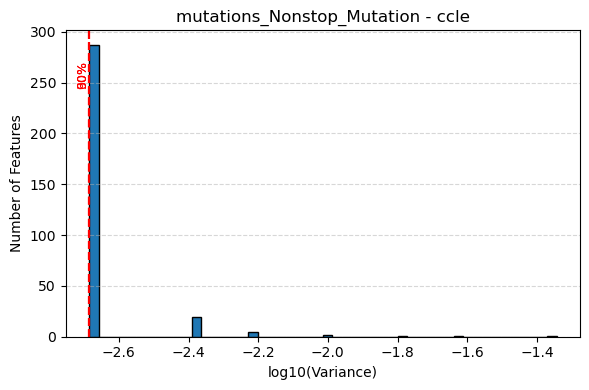

   ⚠️ colorectal: Removed 635 non-positive variances before log10 transform


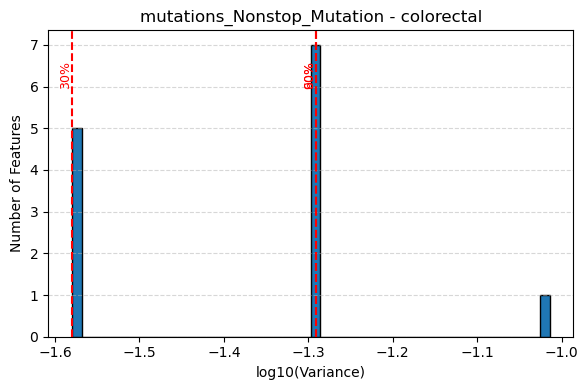

   ⚠️ ctrpv2: Removed 96 non-positive variances before log10 transform


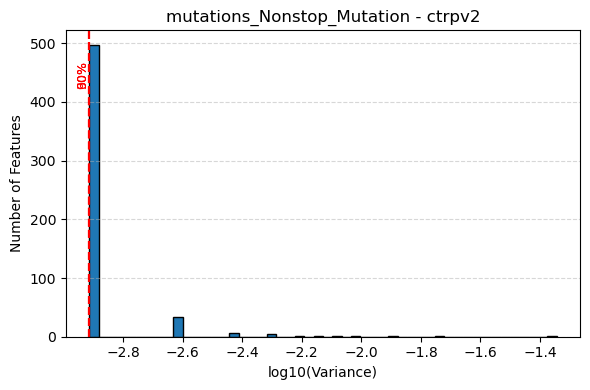

   ⚠️ fimm: Removed 618 non-positive variances before log10 transform


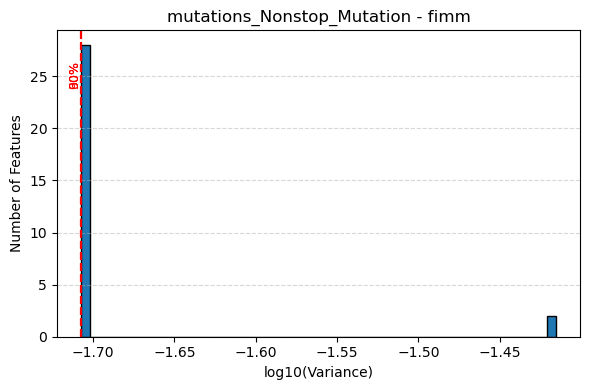

   ⚠️ gcsi: Removed 251 non-positive variances before log10 transform


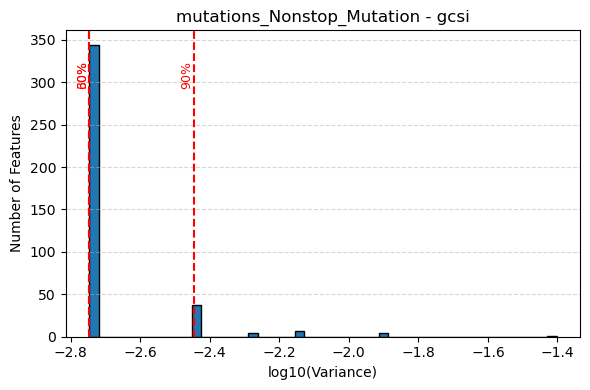

   ⚠️ gdscv1: Removed 648 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Nonstop_Mutation - gdscv1: no positive variances to plot
   ⚠️ gdscv2: Removed 648 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Nonstop_Mutation - gdscv2: no positive variances to plot
   ⚠️ liver: Removed 637 non-positive variances before log10 transform


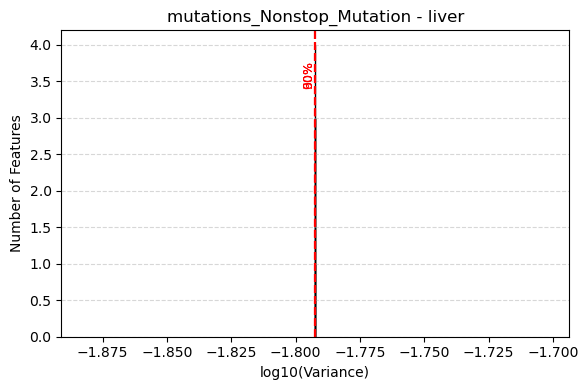

   ⚠️ mpnst: Removed 646 non-positive variances before log10 transform


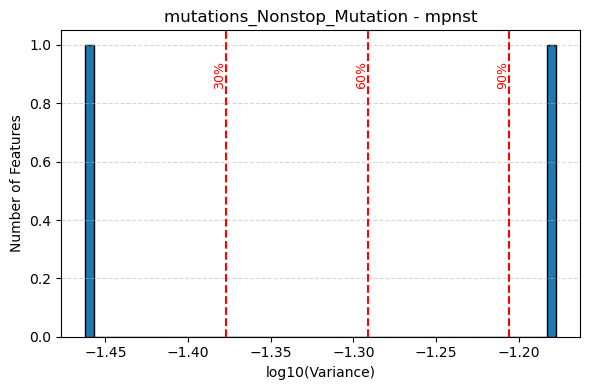

   ⚠️ nci60: Removed 560 non-positive variances before log10 transform


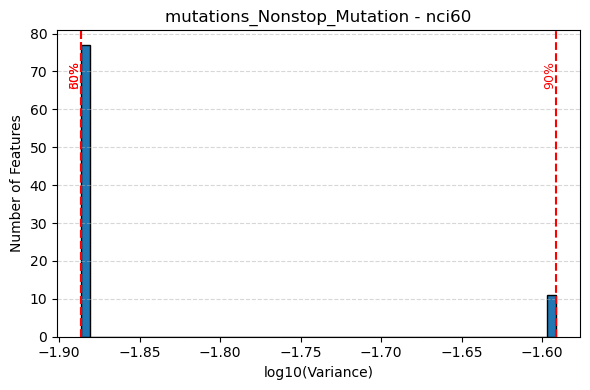

   ⚠️ pancreatic: Removed 648 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Nonstop_Mutation - pancreatic: no positive variances to plot
   ⚠️ prism: Removed 292 non-positive variances before log10 transform


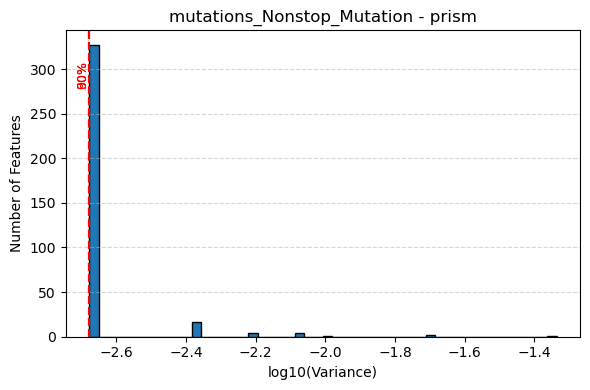

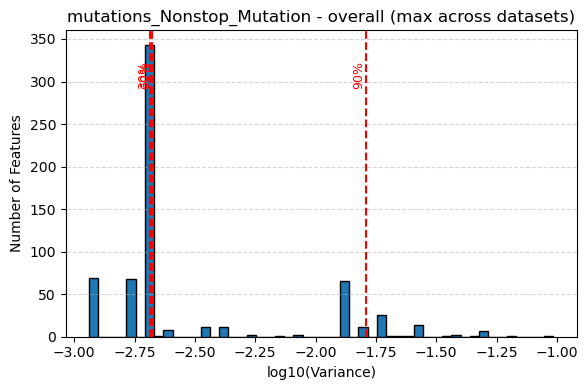

📊 Plotting variance distribution for feature group: mutations_Intron
   ⚠️ beataml: Removed 17083 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Intron - beataml: no positive variances to plot
   ⚠️ bladder: Removed 17082 non-positive variances before log10 transform


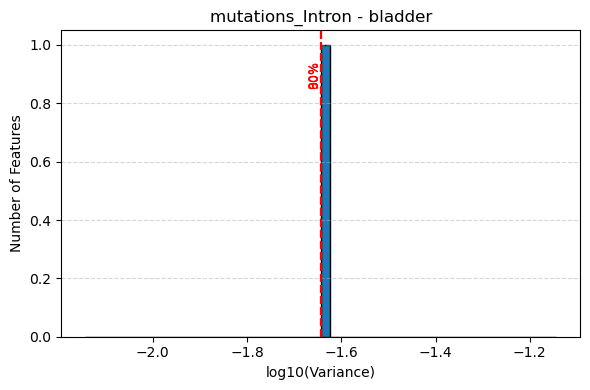

   ⚠️ ccle: Removed 17083 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Intron - ccle: no positive variances to plot
   ⚠️ colorectal: Removed 10622 non-positive variances before log10 transform


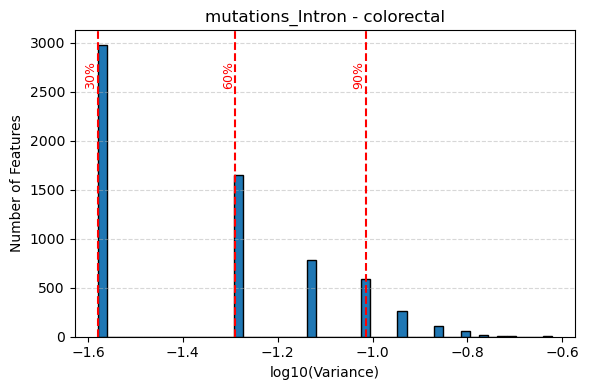

   ⚠️ ctrpv2: Removed 17069 non-positive variances before log10 transform


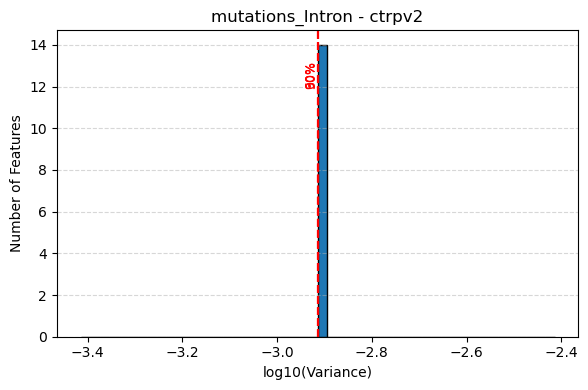

   ⚠️ fimm: Removed 17083 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Intron - fimm: no positive variances to plot
   ⚠️ gcsi: Removed 17069 non-positive variances before log10 transform


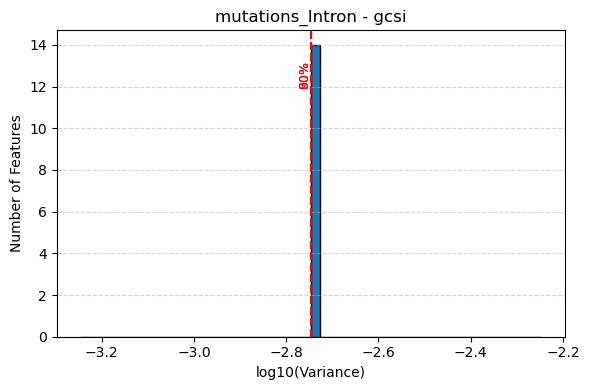

   ⚠️ gdscv1: Removed 644 non-positive variances before log10 transform


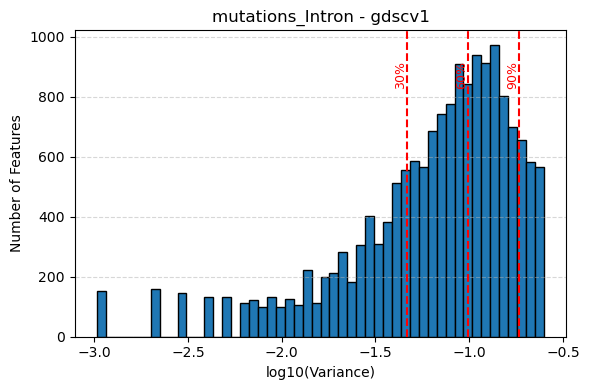

   ⚠️ gdscv2: Removed 666 non-positive variances before log10 transform


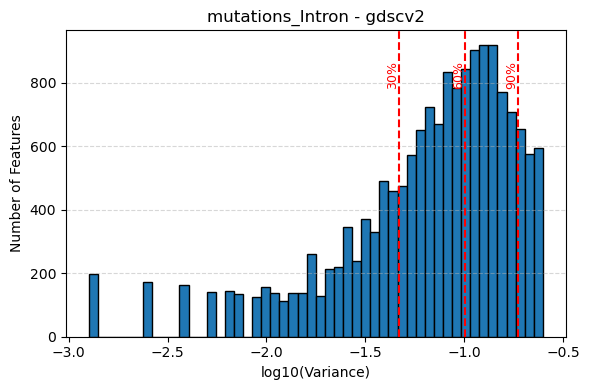

   ⚠️ liver: Removed 17083 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Intron - liver: no positive variances to plot
   ⚠️ mpnst: Removed 6310 non-positive variances before log10 transform


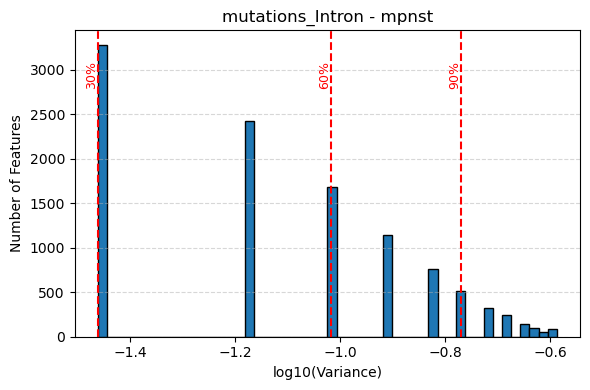

   ⚠️ nci60: Removed 17083 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Intron - nci60: no positive variances to plot
   ⚠️ pancreatic: Removed 14072 non-positive variances before log10 transform


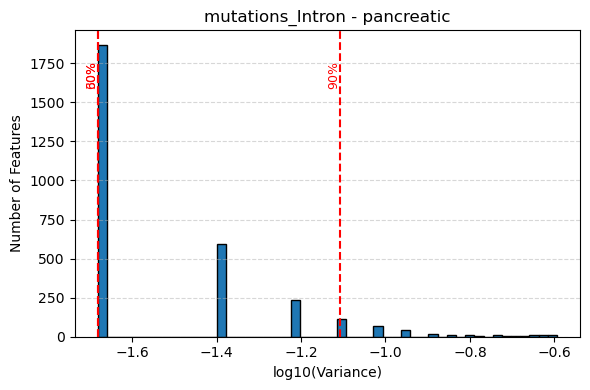

   ⚠️ prism: Removed 17083 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Intron - prism: no positive variances to plot


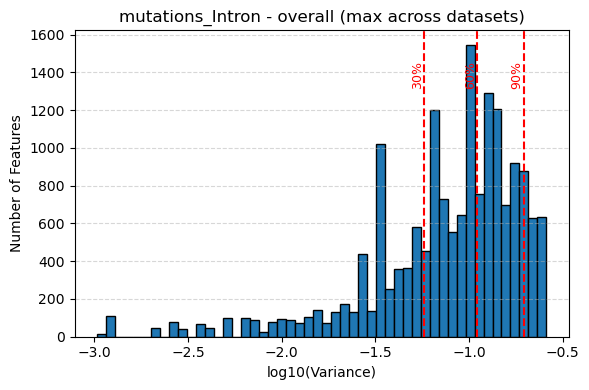

📊 Plotting variance distribution for feature group: mutations_3'Flank
   ⚠️ beataml: Removed 3472 non-positive variances before log10 transform
   ⚠️ Skipping mutations_3'Flank - beataml: no positive variances to plot
   ⚠️ bladder: Removed 3472 non-positive variances before log10 transform
   ⚠️ Skipping mutations_3'Flank - bladder: no positive variances to plot
   ⚠️ ccle: Removed 3472 non-positive variances before log10 transform
   ⚠️ Skipping mutations_3'Flank - ccle: no positive variances to plot
   ⚠️ colorectal: Removed 3472 non-positive variances before log10 transform
   ⚠️ Skipping mutations_3'Flank - colorectal: no positive variances to plot
   ⚠️ ctrpv2: Removed 3472 non-positive variances before log10 transform
   ⚠️ Skipping mutations_3'Flank - ctrpv2: no positive variances to plot
   ⚠️ fimm: Removed 3472 non-positive variances before log10 transform
   ⚠️ Skipping mutations_3'Flank - fimm: no positive variances to plot
   ⚠️ gcsi: Removed 3472 non-positive variances be

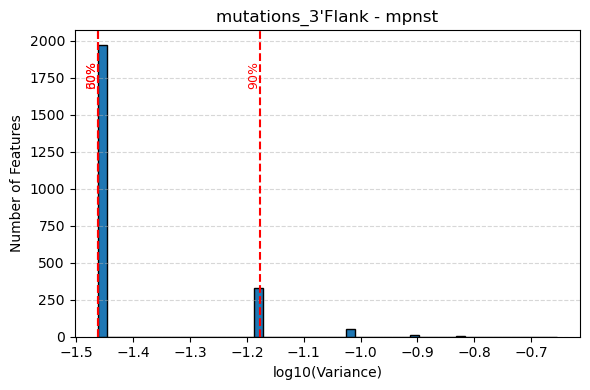

   ⚠️ nci60: Removed 3472 non-positive variances before log10 transform
   ⚠️ Skipping mutations_3'Flank - nci60: no positive variances to plot
   ⚠️ pancreatic: Removed 2257 non-positive variances before log10 transform


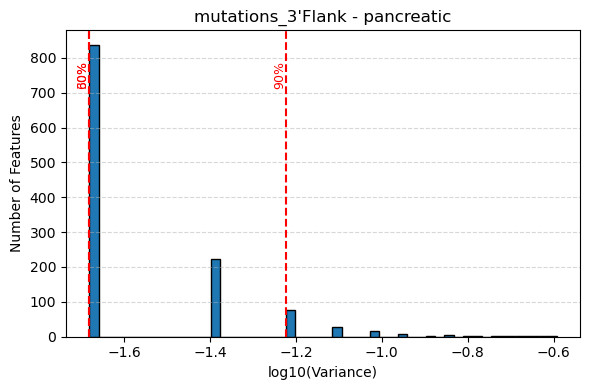

   ⚠️ prism: Removed 3472 non-positive variances before log10 transform
   ⚠️ Skipping mutations_3'Flank - prism: no positive variances to plot


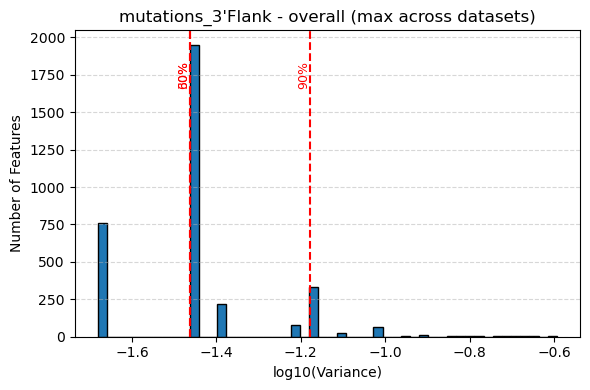

📊 Plotting variance distribution for feature group: mutations_Frame_Shift_Ins
   ⚠️ beataml: Removed 6140 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Frame_Shift_Ins - beataml: no positive variances to plot
   ⚠️ bladder: Removed 6122 non-positive variances before log10 transform


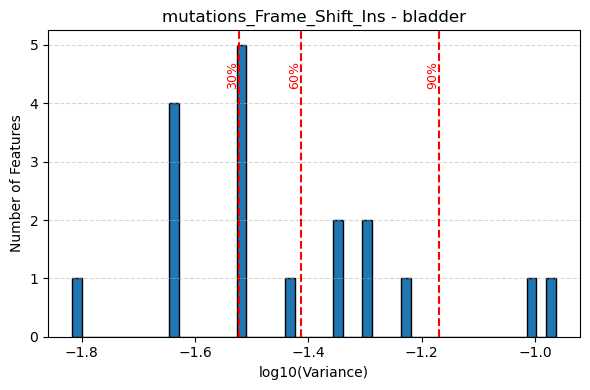

   ⚠️ ccle: Removed 1957 non-positive variances before log10 transform


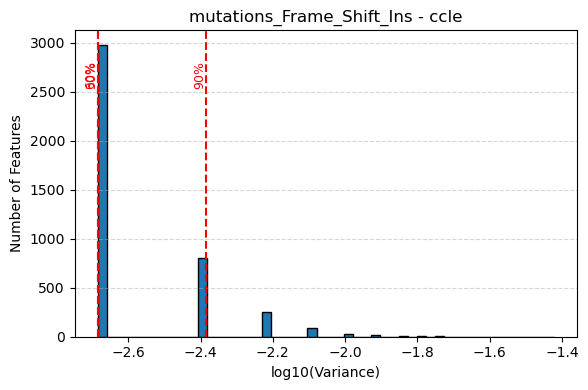

   ⚠️ colorectal: Removed 5819 non-positive variances before log10 transform


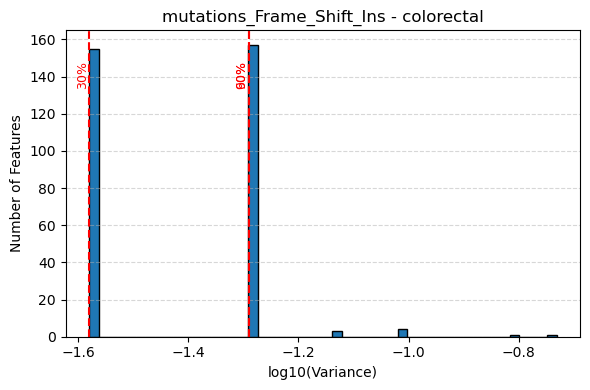

   ⚠️ ctrpv2: Removed 536 non-positive variances before log10 transform


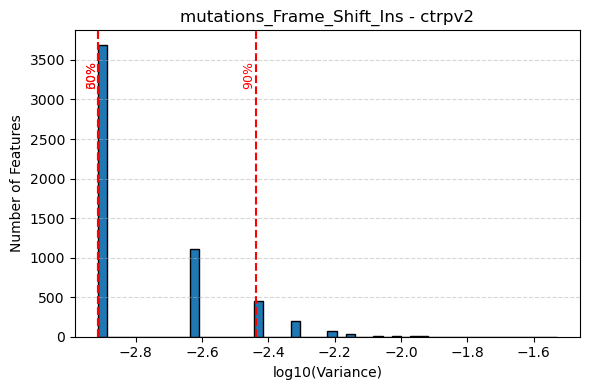

   ⚠️ fimm: Removed 5886 non-positive variances before log10 transform


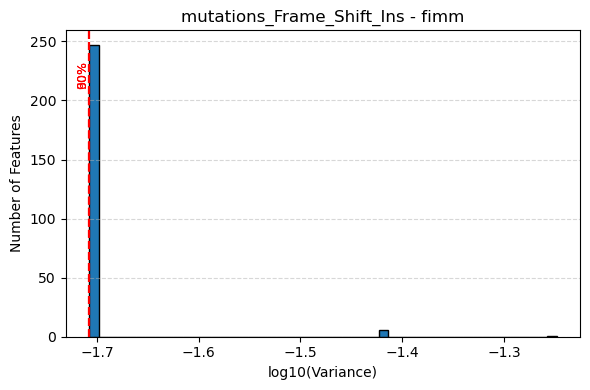

   ⚠️ gcsi: Removed 2131 non-positive variances before log10 transform


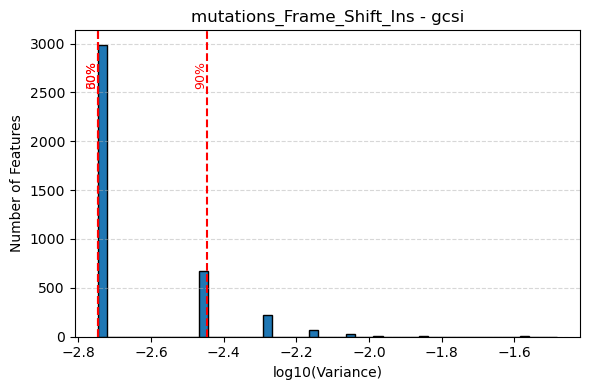

   ⚠️ gdscv1: Removed 6140 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Frame_Shift_Ins - gdscv1: no positive variances to plot
   ⚠️ gdscv2: Removed 6140 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Frame_Shift_Ins - gdscv2: no positive variances to plot
   ⚠️ liver: Removed 5834 non-positive variances before log10 transform


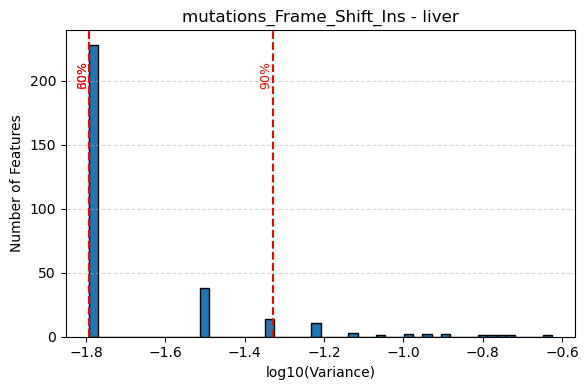

   ⚠️ mpnst: Removed 6123 non-positive variances before log10 transform


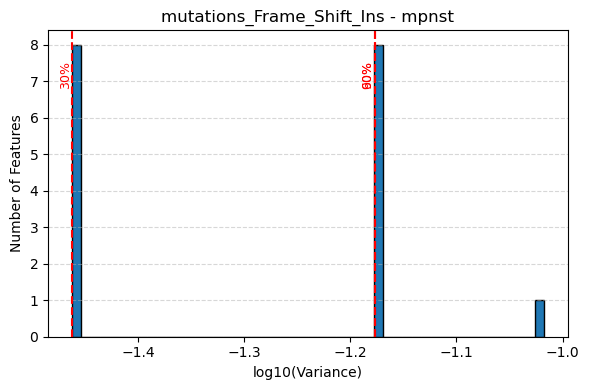

   ⚠️ nci60: Removed 5433 non-positive variances before log10 transform


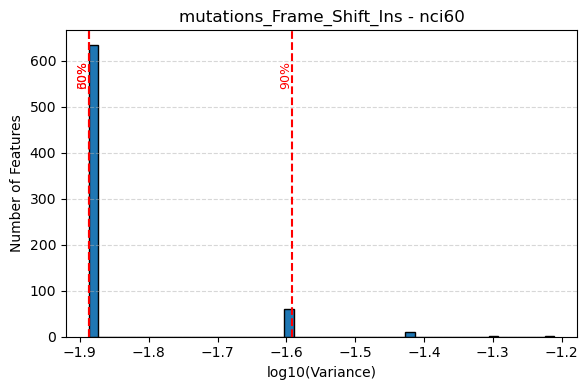

   ⚠️ pancreatic: Removed 6140 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Frame_Shift_Ins - pancreatic: no positive variances to plot
   ⚠️ prism: Removed 1635 non-positive variances before log10 transform


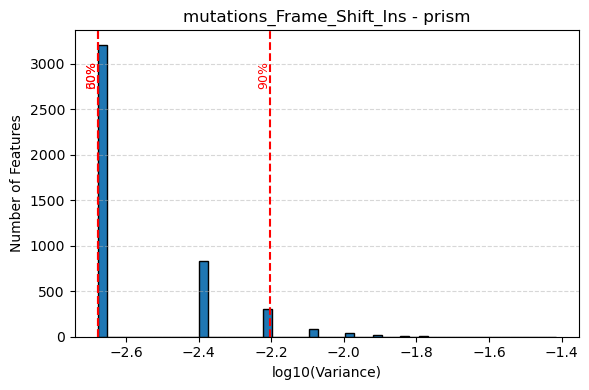

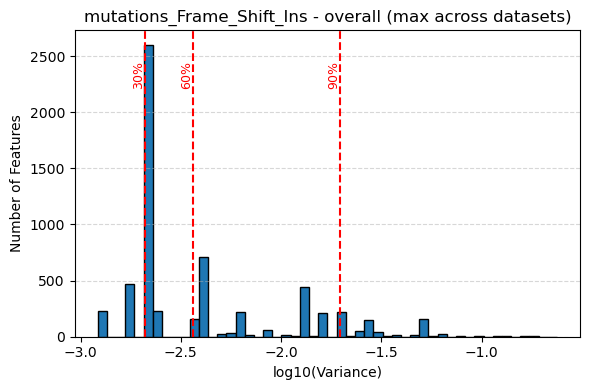

📊 Plotting variance distribution for feature group: mutations_Frame_Shift_Del
   ⚠️ beataml: Removed 13800 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Frame_Shift_Del - beataml: no positive variances to plot
   ⚠️ bladder: Removed 13760 non-positive variances before log10 transform


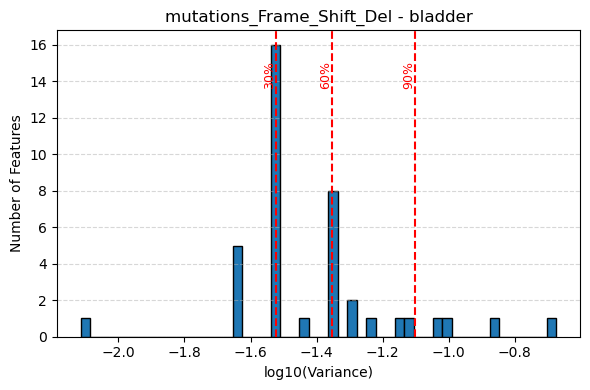

   ⚠️ ccle: Removed 6454 non-positive variances before log10 transform


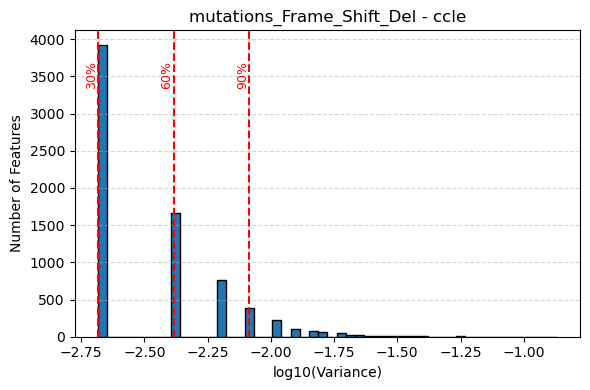

   ⚠️ colorectal: Removed 12754 non-positive variances before log10 transform


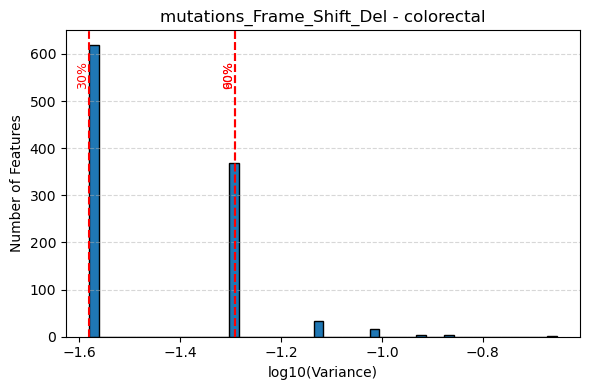

   ⚠️ ctrpv2: Removed 4317 non-positive variances before log10 transform


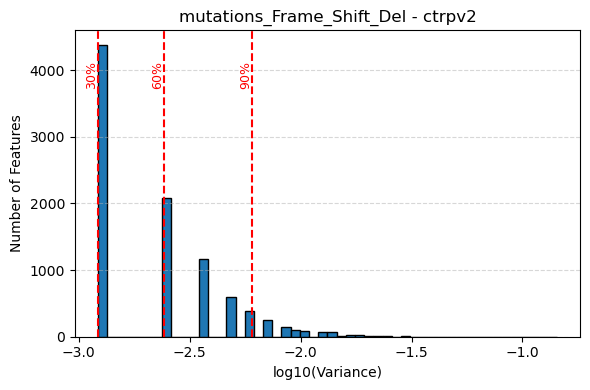

   ⚠️ fimm: Removed 13027 non-positive variances before log10 transform


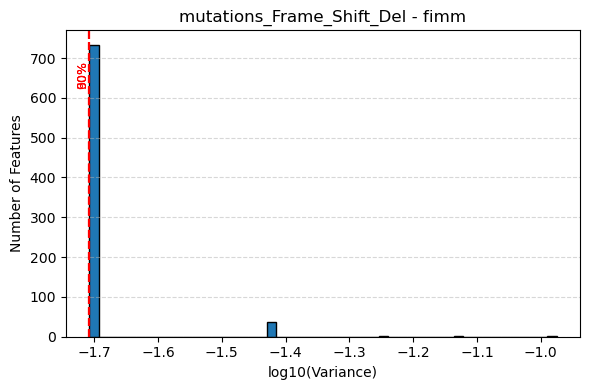

   ⚠️ gcsi: Removed 6002 non-positive variances before log10 transform


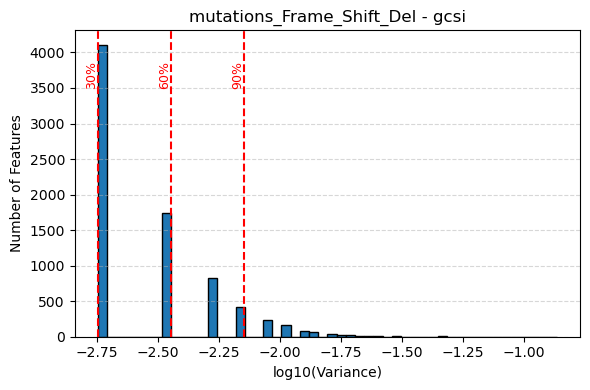

   ⚠️ gdscv1: Removed 1278 non-positive variances before log10 transform


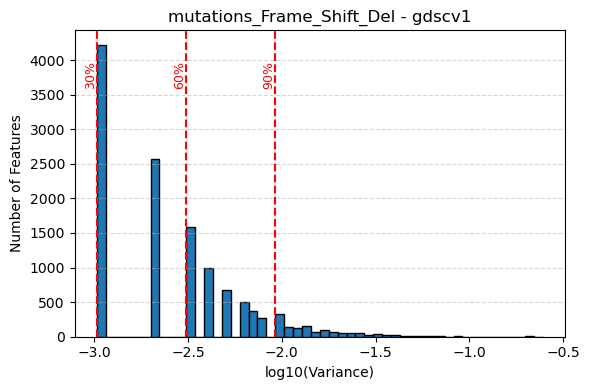

   ⚠️ gdscv2: Removed 1646 non-positive variances before log10 transform


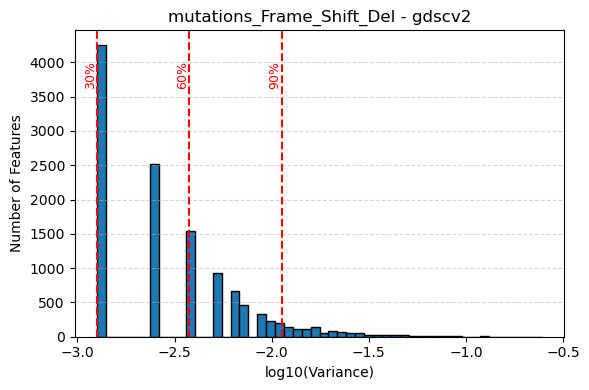

   ⚠️ liver: Removed 13252 non-positive variances before log10 transform


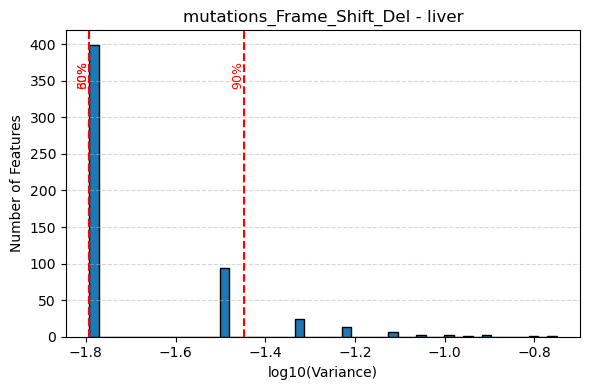

   ⚠️ mpnst: Removed 13748 non-positive variances before log10 transform


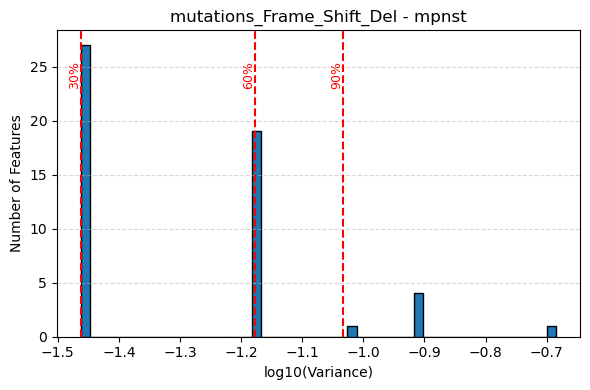

   ⚠️ nci60: Removed 11586 non-positive variances before log10 transform


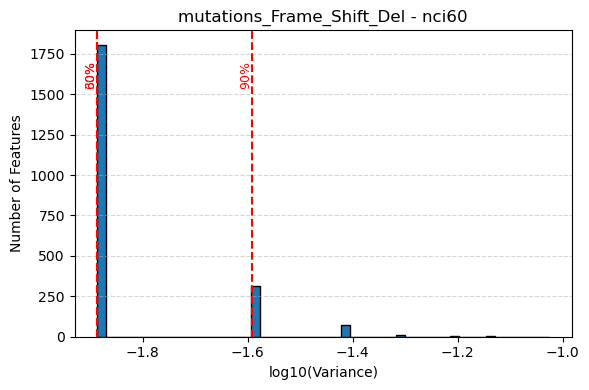

   ⚠️ pancreatic: Removed 13800 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Frame_Shift_Del - pancreatic: no positive variances to plot
   ⚠️ prism: Removed 5730 non-positive variances before log10 transform


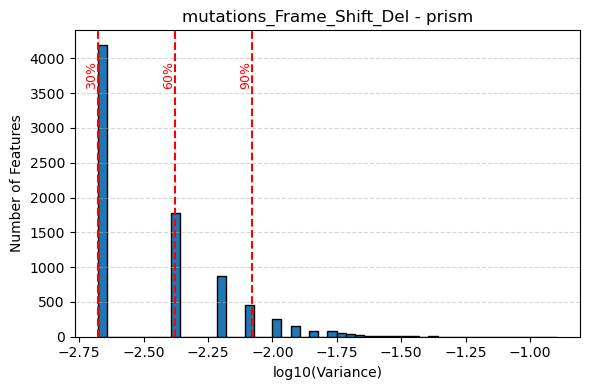

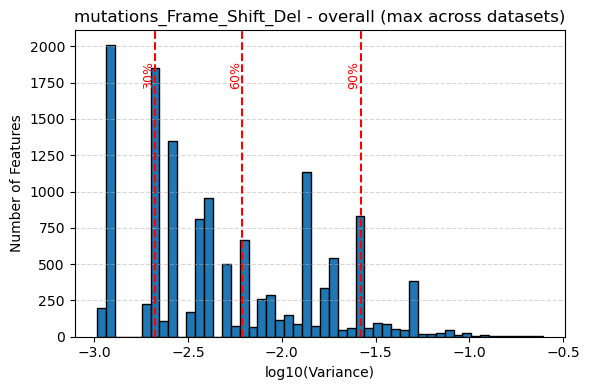

📊 Plotting variance distribution for feature group: mutations_In_Frame_Ins
   ⚠️ beataml: Removed 885 non-positive variances before log10 transform


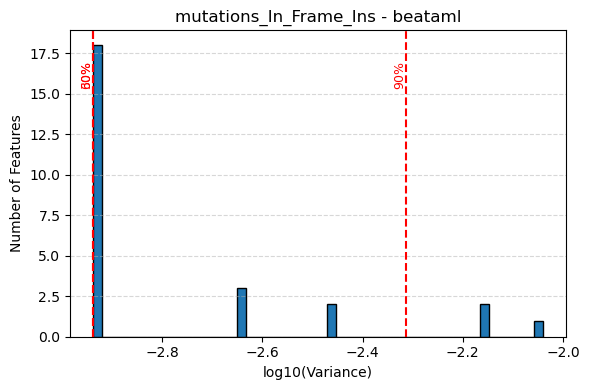

   ⚠️ bladder: Removed 893 non-positive variances before log10 transform


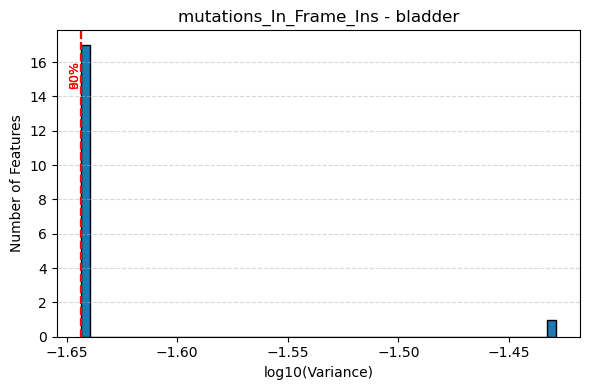

   ⚠️ ccle: Removed 589 non-positive variances before log10 transform


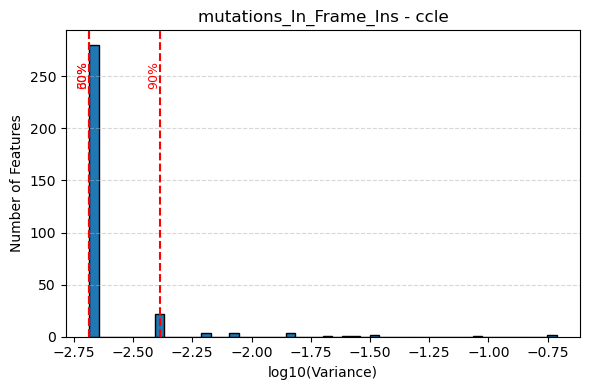

   ⚠️ colorectal: Removed 881 non-positive variances before log10 transform


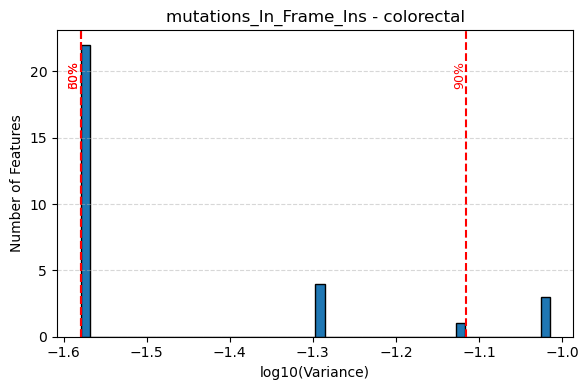

   ⚠️ ctrpv2: Removed 430 non-positive variances before log10 transform


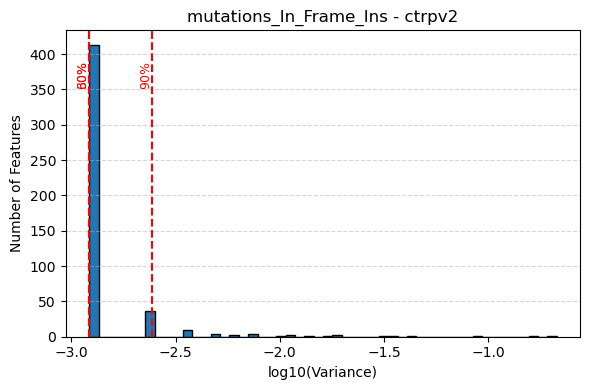

   ⚠️ fimm: Removed 876 non-positive variances before log10 transform


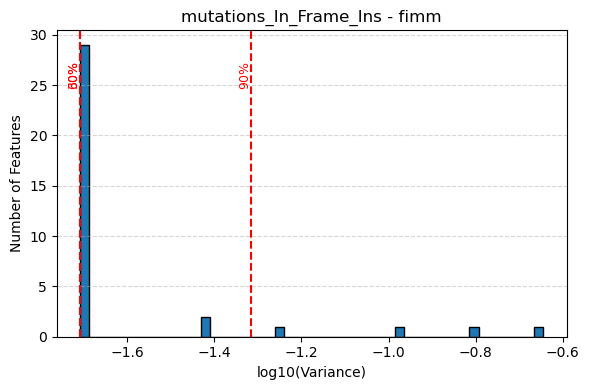

   ⚠️ gcsi: Removed 559 non-positive variances before log10 transform


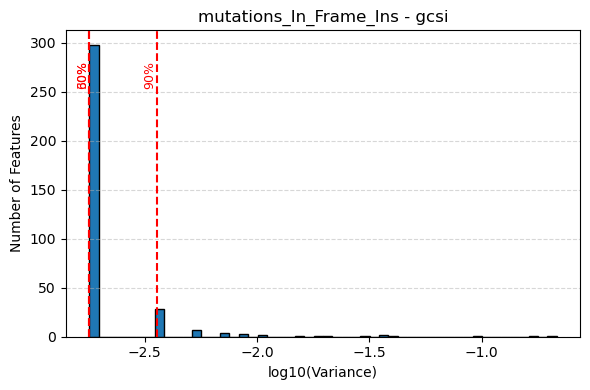

   ⚠️ gdscv1: Removed 911 non-positive variances before log10 transform
   ⚠️ Skipping mutations_In_Frame_Ins - gdscv1: no positive variances to plot
   ⚠️ gdscv2: Removed 911 non-positive variances before log10 transform
   ⚠️ Skipping mutations_In_Frame_Ins - gdscv2: no positive variances to plot
   ⚠️ liver: Removed 813 non-positive variances before log10 transform


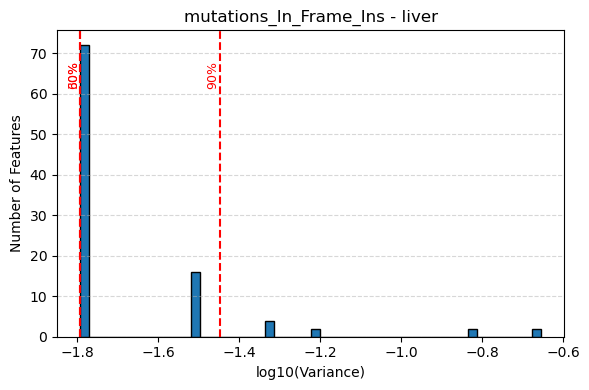

   ⚠️ mpnst: Removed 848 non-positive variances before log10 transform


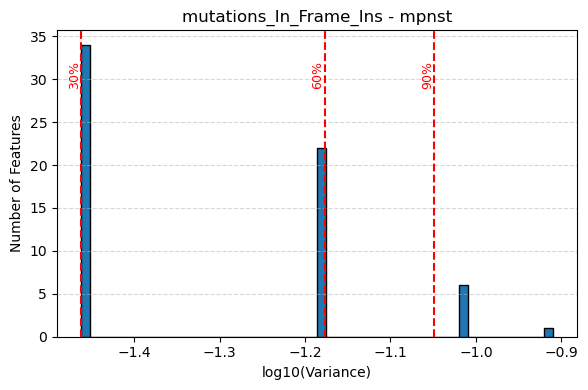

   ⚠️ nci60: Removed 853 non-positive variances before log10 transform


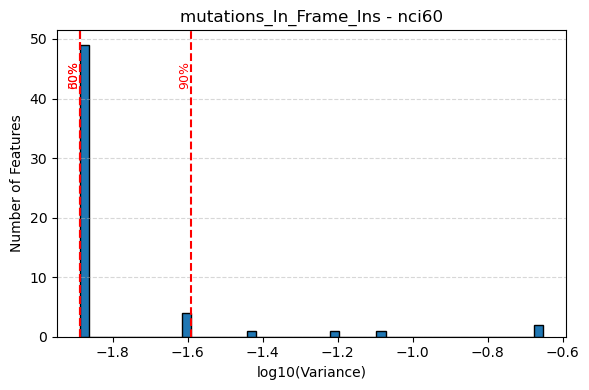

   ⚠️ pancreatic: Removed 689 non-positive variances before log10 transform


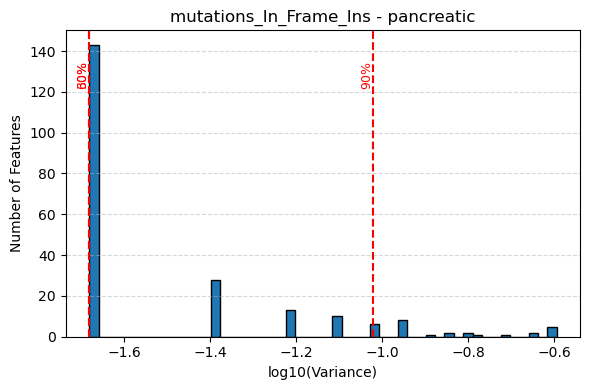

   ⚠️ prism: Removed 615 non-positive variances before log10 transform


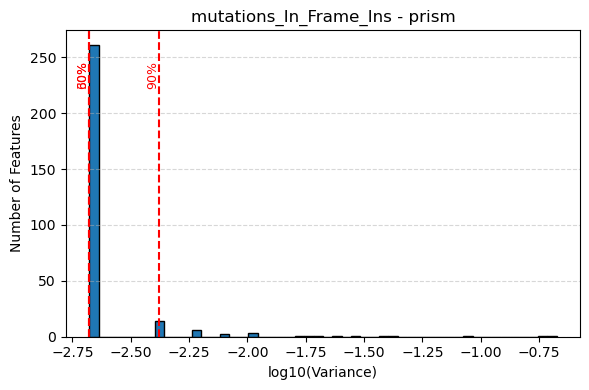

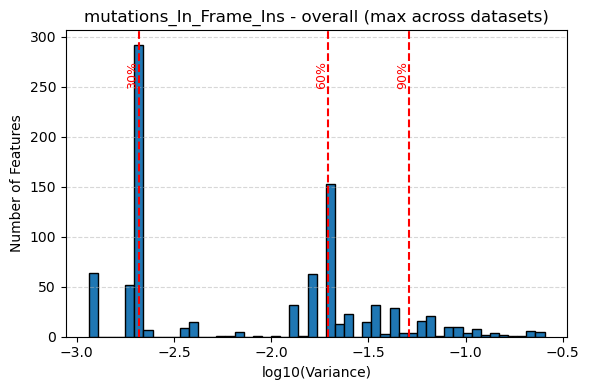

📊 Plotting variance distribution for feature group: mutations_Silent
   ⚠️ beataml: Removed 18322 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Silent - beataml: no positive variances to plot
   ⚠️ bladder: Removed 18322 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Silent - bladder: no positive variances to plot
   ⚠️ ccle: Removed 1419 non-positive variances before log10 transform


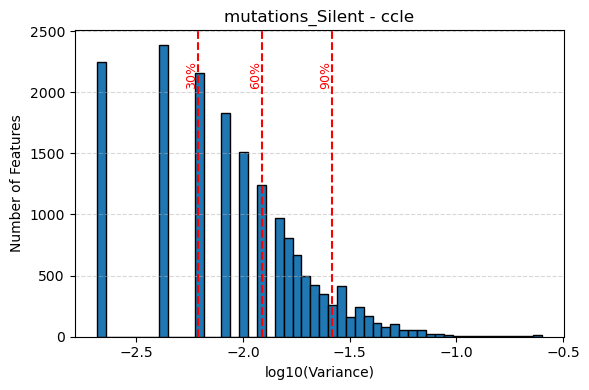

   ⚠️ colorectal: Removed 15671 non-positive variances before log10 transform


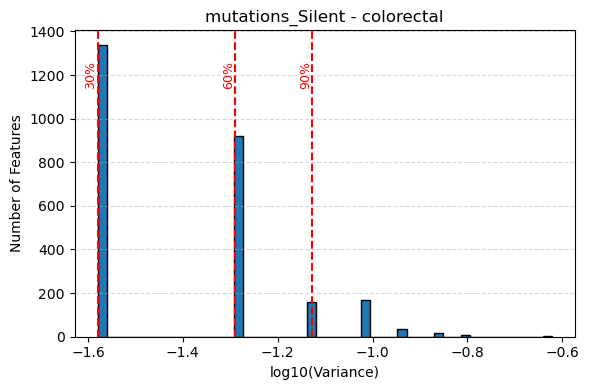

   ⚠️ ctrpv2: Removed 484 non-positive variances before log10 transform


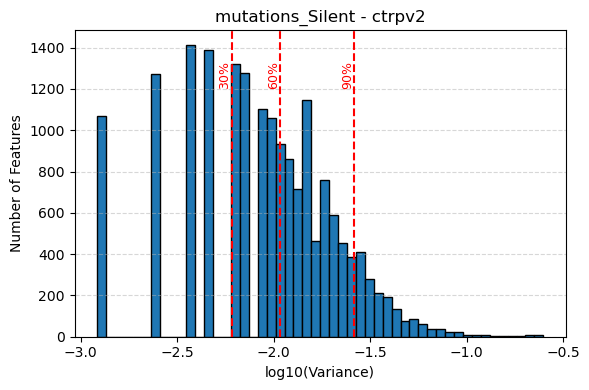

   ⚠️ fimm: Removed 13121 non-positive variances before log10 transform


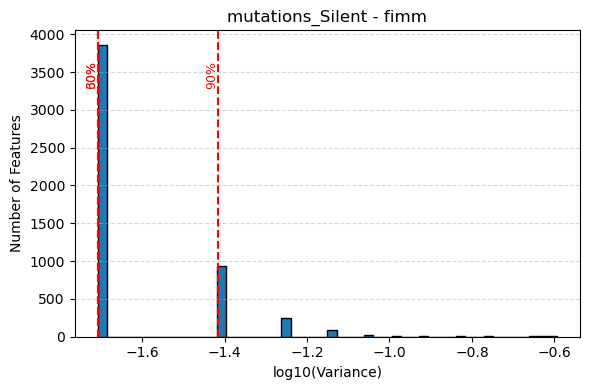

   ⚠️ gcsi: Removed 969 non-positive variances before log10 transform


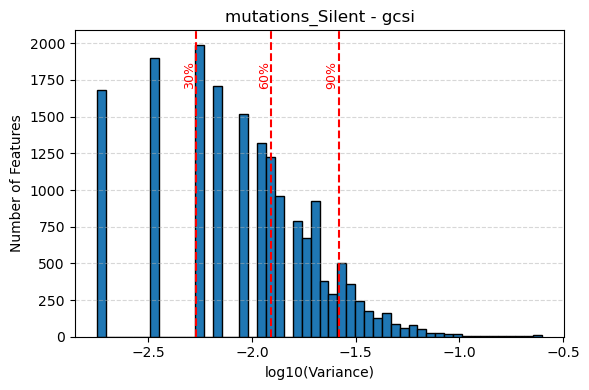

   ⚠️ gdscv1: Removed 17998 non-positive variances before log10 transform


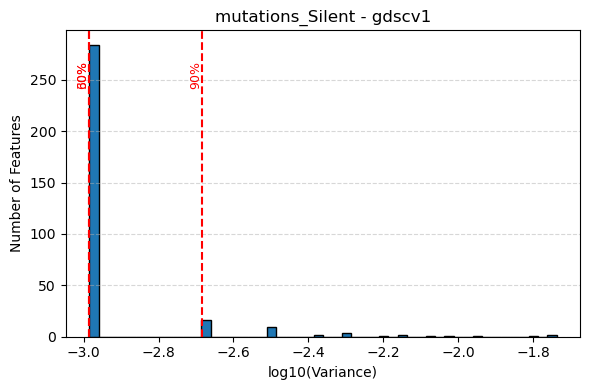

   ⚠️ gdscv2: Removed 18037 non-positive variances before log10 transform


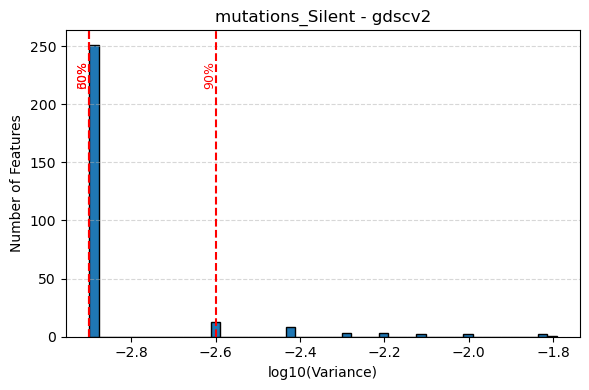

   ⚠️ liver: Removed 18322 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Silent - liver: no positive variances to plot
   ⚠️ mpnst: Removed 16783 non-positive variances before log10 transform


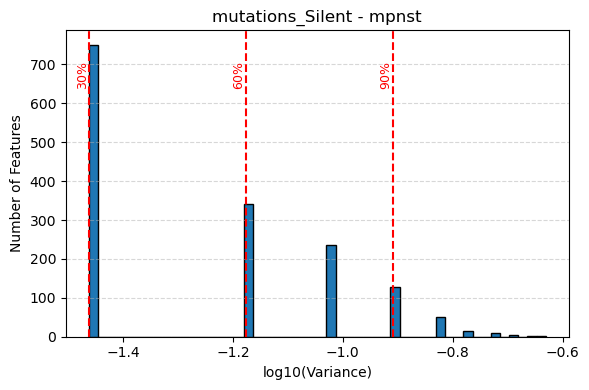

   ⚠️ nci60: Removed 7978 non-positive variances before log10 transform


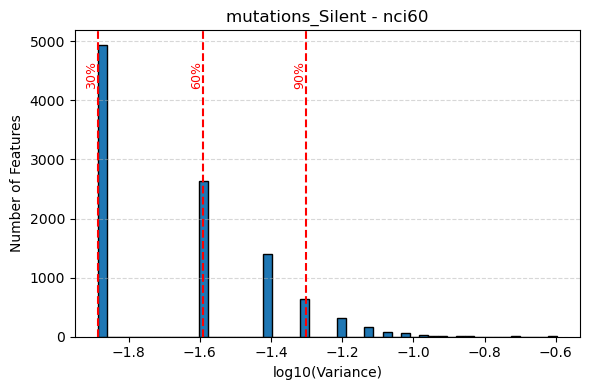

   ⚠️ pancreatic: Removed 10408 non-positive variances before log10 transform


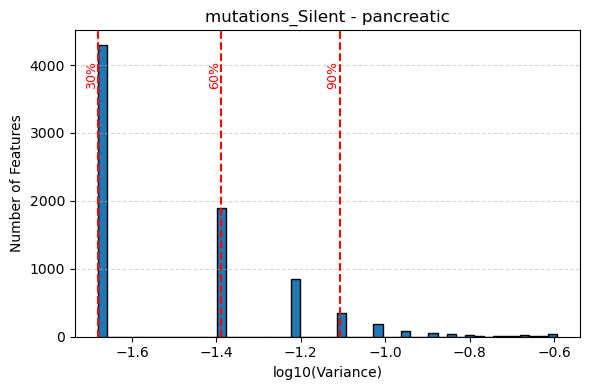

   ⚠️ prism: Removed 1218 non-positive variances before log10 transform


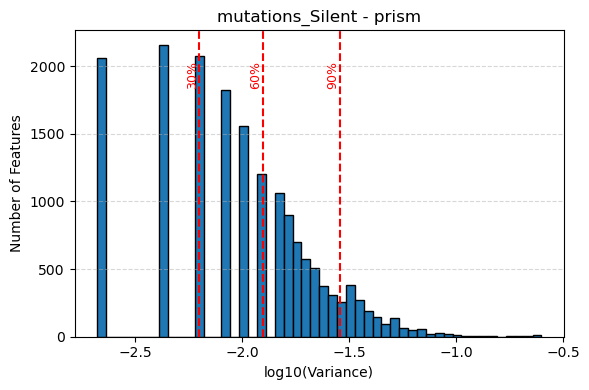

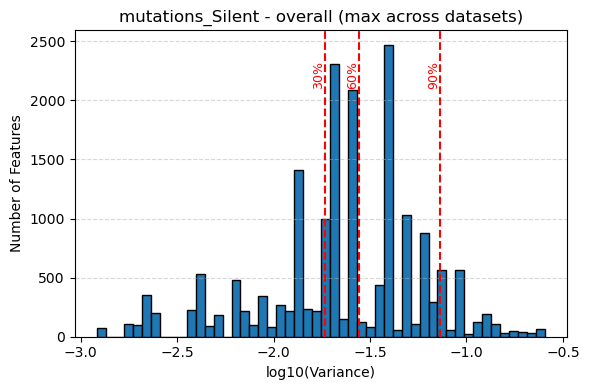

📊 Plotting variance distribution for feature group: mutations_5'Flank
   ⚠️ beataml: Removed 15170 non-positive variances before log10 transform
   ⚠️ Skipping mutations_5'Flank - beataml: no positive variances to plot
   ⚠️ bladder: Removed 15169 non-positive variances before log10 transform


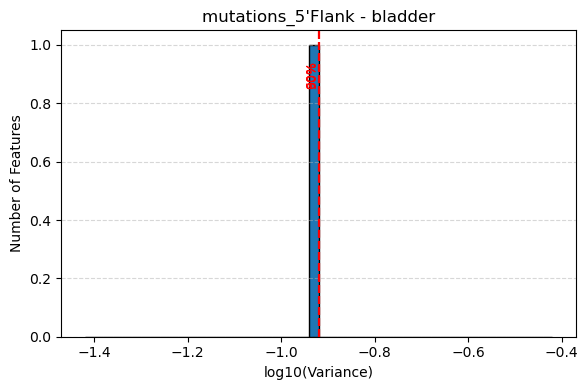

   ⚠️ ccle: Removed 15170 non-positive variances before log10 transform
   ⚠️ Skipping mutations_5'Flank - ccle: no positive variances to plot
   ⚠️ colorectal: Removed 14909 non-positive variances before log10 transform


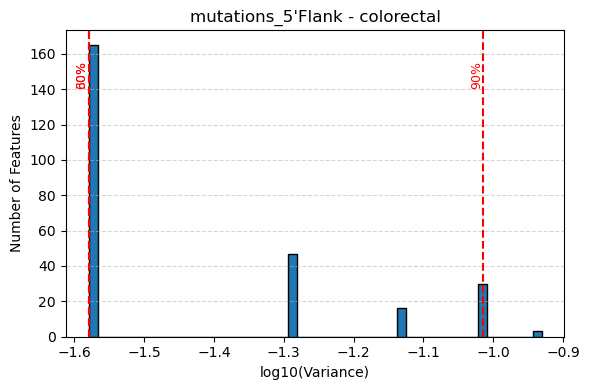

   ⚠️ ctrpv2: Removed 15170 non-positive variances before log10 transform
   ⚠️ Skipping mutations_5'Flank - ctrpv2: no positive variances to plot
   ⚠️ fimm: Removed 15170 non-positive variances before log10 transform
   ⚠️ Skipping mutations_5'Flank - fimm: no positive variances to plot
   ⚠️ gcsi: Removed 15170 non-positive variances before log10 transform
   ⚠️ Skipping mutations_5'Flank - gcsi: no positive variances to plot
   ⚠️ gdscv1: Removed 950 non-positive variances before log10 transform


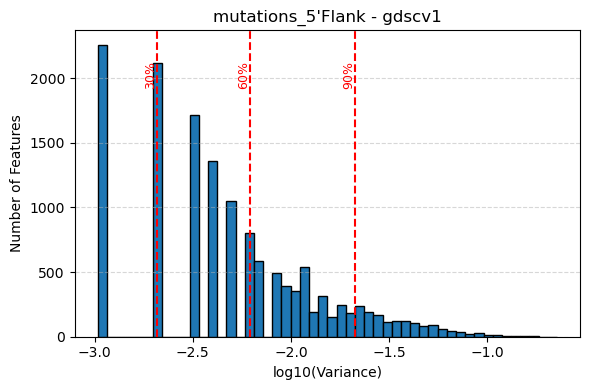

   ⚠️ gdscv2: Removed 1394 non-positive variances before log10 transform


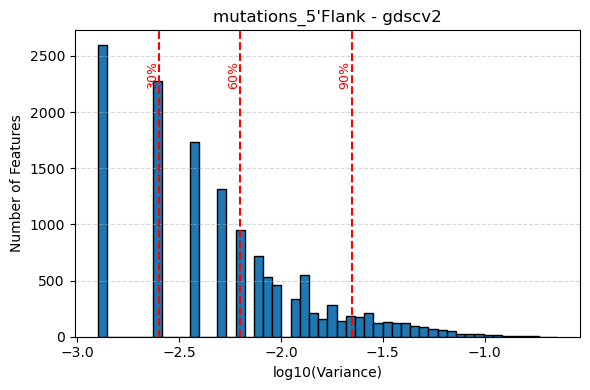

   ⚠️ liver: Removed 15170 non-positive variances before log10 transform
   ⚠️ Skipping mutations_5'Flank - liver: no positive variances to plot
   ⚠️ mpnst: Removed 12182 non-positive variances before log10 transform


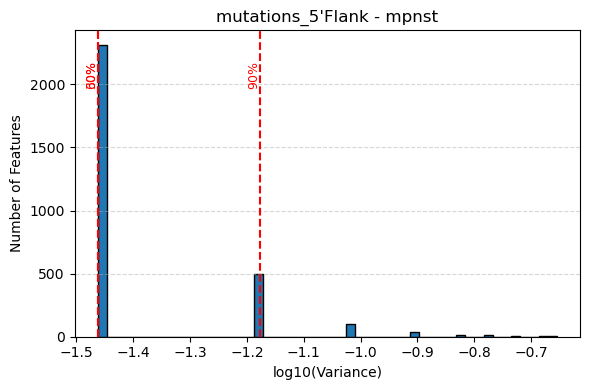

   ⚠️ nci60: Removed 15170 non-positive variances before log10 transform
   ⚠️ Skipping mutations_5'Flank - nci60: no positive variances to plot
   ⚠️ pancreatic: Removed 13493 non-positive variances before log10 transform


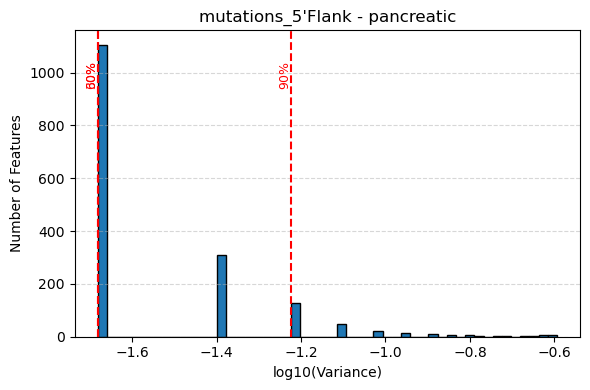

   ⚠️ prism: Removed 15170 non-positive variances before log10 transform
   ⚠️ Skipping mutations_5'Flank - prism: no positive variances to plot


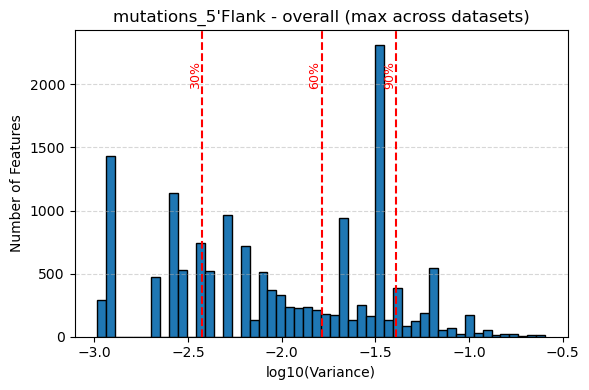

📊 Plotting variance distribution for feature group: mutations_Translation_Start_Site
   ⚠️ beataml: Removed 913 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Translation_Start_Site - beataml: no positive variances to plot
   ⚠️ bladder: Removed 911 non-positive variances before log10 transform


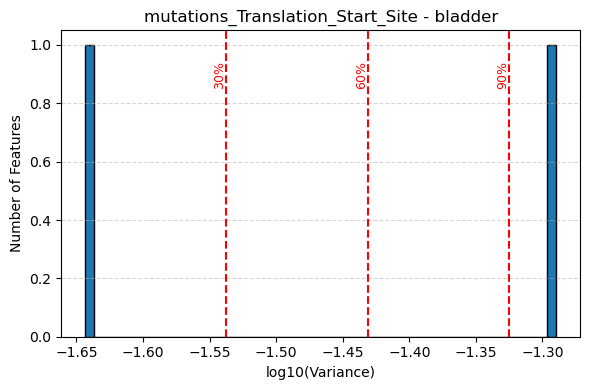

   ⚠️ ccle: Removed 913 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Translation_Start_Site - ccle: no positive variances to plot
   ⚠️ colorectal: Removed 913 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Translation_Start_Site - colorectal: no positive variances to plot
   ⚠️ ctrpv2: Removed 913 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Translation_Start_Site - ctrpv2: no positive variances to plot
   ⚠️ fimm: Removed 913 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Translation_Start_Site - fimm: no positive variances to plot
   ⚠️ gcsi: Removed 913 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Translation_Start_Site - gcsi: no positive variances to plot
   ⚠️ gdscv1: Removed 15 non-positive variances before log10 transform


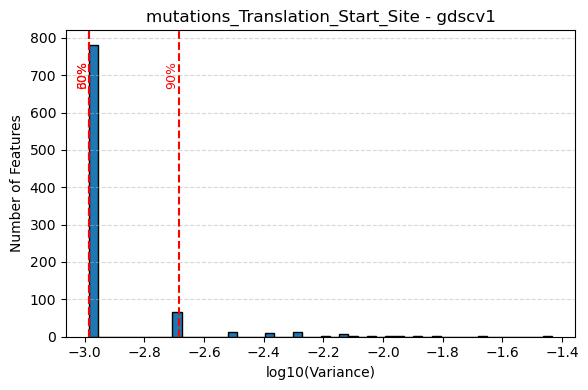

   ⚠️ gdscv2: Removed 140 non-positive variances before log10 transform


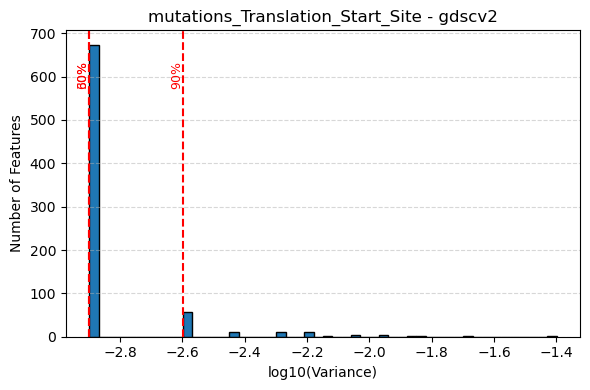

   ⚠️ liver: Removed 903 non-positive variances before log10 transform


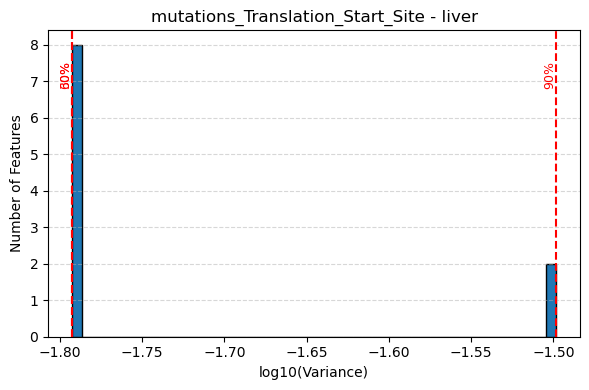

   ⚠️ mpnst: Removed 909 non-positive variances before log10 transform


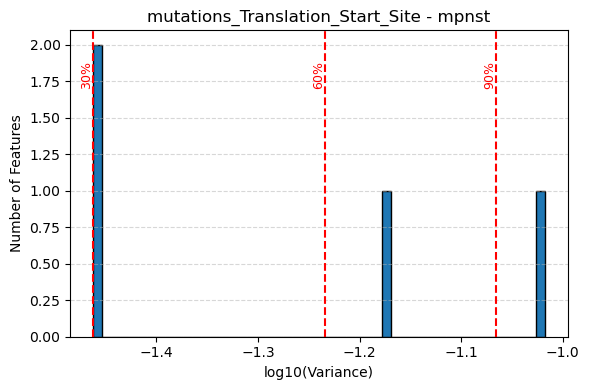

   ⚠️ nci60: Removed 913 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Translation_Start_Site - nci60: no positive variances to plot
   ⚠️ pancreatic: Removed 913 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Translation_Start_Site - pancreatic: no positive variances to plot
   ⚠️ prism: Removed 913 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Translation_Start_Site - prism: no positive variances to plot


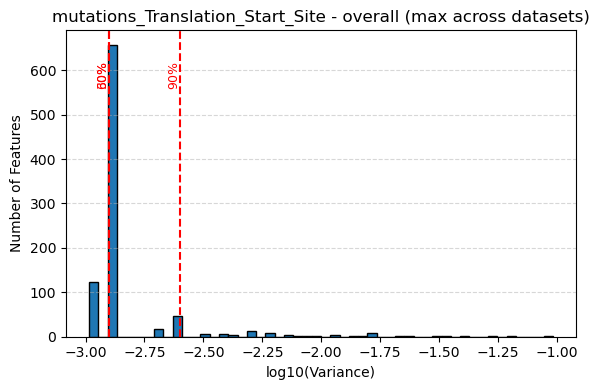

📊 Plotting variance distribution for feature group: mutations_Start_Codon_SNP
   ⚠️ beataml: Removed 900 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Start_Codon_SNP - beataml: no positive variances to plot
   ⚠️ bladder: Removed 900 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Start_Codon_SNP - bladder: no positive variances to plot
   ⚠️ ccle: Removed 418 non-positive variances before log10 transform


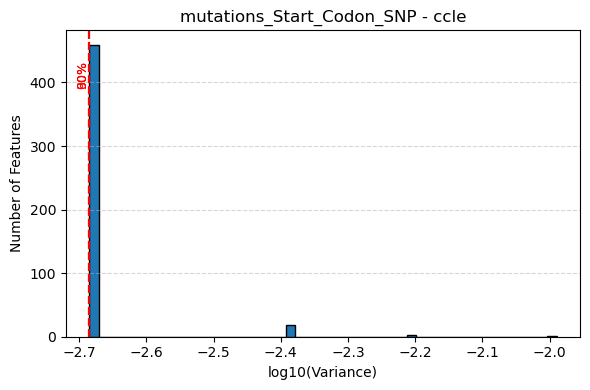

   ⚠️ colorectal: Removed 899 non-positive variances before log10 transform


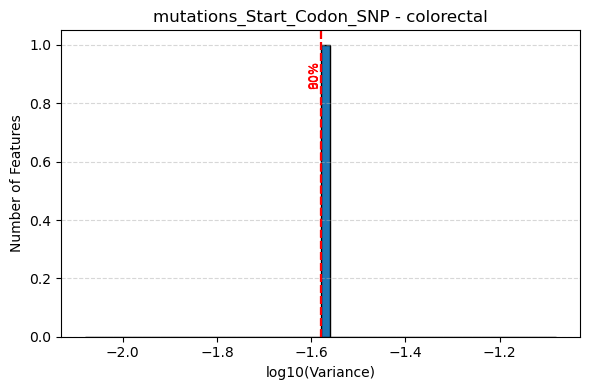

   ⚠️ ctrpv2: Removed 98 non-positive variances before log10 transform


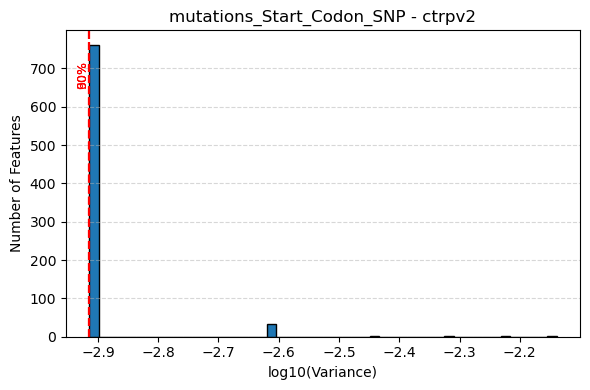

   ⚠️ fimm: Removed 865 non-positive variances before log10 transform


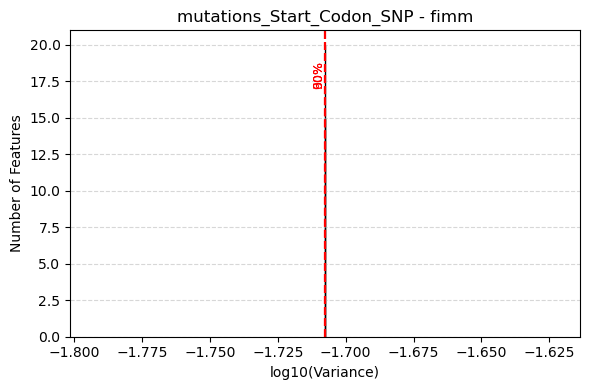

   ⚠️ gcsi: Removed 349 non-positive variances before log10 transform


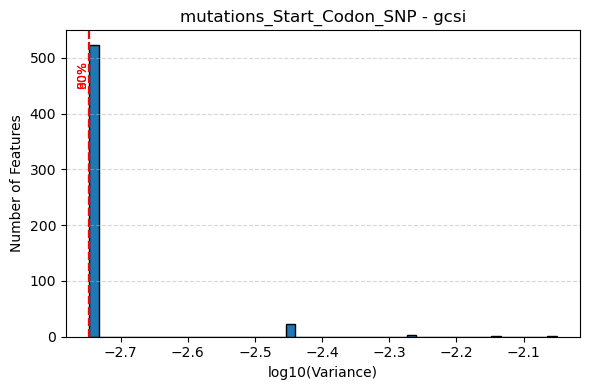

   ⚠️ gdscv1: Removed 900 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Start_Codon_SNP - gdscv1: no positive variances to plot
   ⚠️ gdscv2: Removed 900 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Start_Codon_SNP - gdscv2: no positive variances to plot
   ⚠️ liver: Removed 900 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Start_Codon_SNP - liver: no positive variances to plot
   ⚠️ mpnst: Removed 900 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Start_Codon_SNP - mpnst: no positive variances to plot
   ⚠️ nci60: Removed 811 non-positive variances before log10 transform


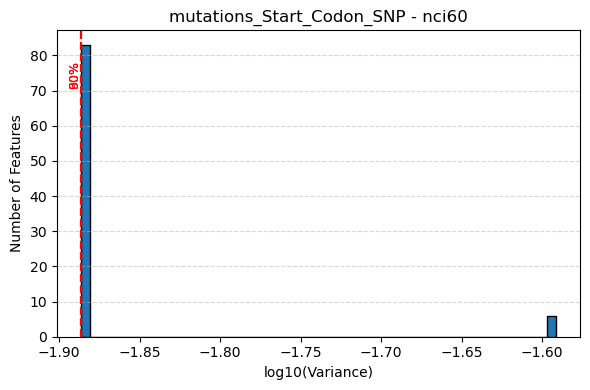

   ⚠️ pancreatic: Removed 900 non-positive variances before log10 transform
   ⚠️ Skipping mutations_Start_Codon_SNP - pancreatic: no positive variances to plot
   ⚠️ prism: Removed 389 non-positive variances before log10 transform


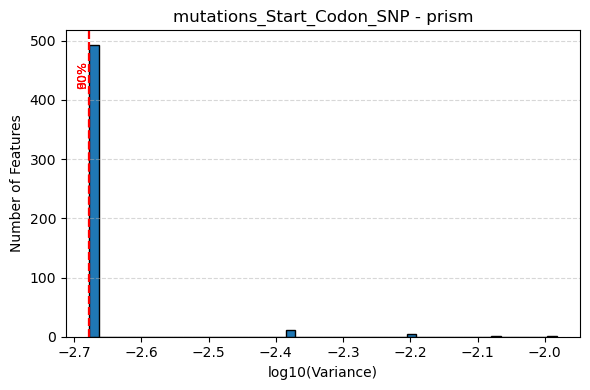

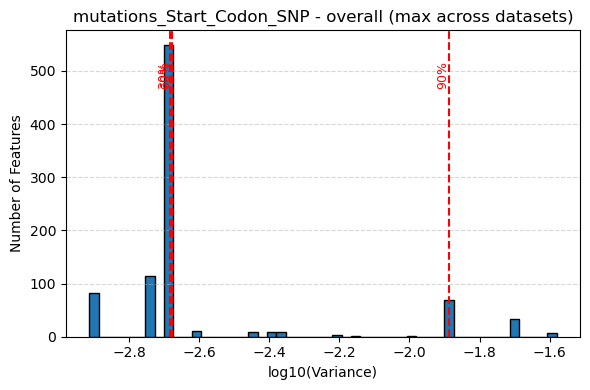

In [ ]:
importlib.reload(coderdata_processing)
from coderdata_processing import plot_feature_variance_distribution

plot_feature_variance_distribution(unified_datasets)

In [ ]:
importlib.reload(coderdata_processing)
from coderdata_processing import filter_feature, filter_biomarkers, unify_cell_ids_across_dfs

feature_reduced_dfs = filter_biomarkers(unified_datasets, data_size_ref, proportion=1e-2)

feature_reduced_dfs = unify_cell_ids_across_dfs(feature_reduced_dfs)

dim_reduced_dfs = filter_feature(feature_reduced_dfs)

Feature mutations_Protein_Altering_Variant is filtered out due to insufficient samples, more than 1.0% samples required in at least 50% datasets.
Feature mutations_Stop_Codon_Del is filtered out due to insufficient samples, more than 1.0% samples required in at least 50% datasets.
Feature mutations_Frameshift_Variant is filtered out due to insufficient samples, more than 1.0% samples required in at least 50% datasets.
Feature mutations_Intron is filtered out due to insufficient samples, more than 1.0% samples required in at least 50% datasets.
Feature mutations_5'Flank is filtered out due to insufficient samples, more than 1.0% samples required in at least 50% datasets.
Feature mutations_3'Flank is filtered out due to insufficient samples, more than 1.0% samples required in at least 50% datasets.
Feature mutations_Stop_Codon_Ins is filtered out due to insufficient samples, more than 1.0% samples required in at least 50% datasets.
Feature mutations_Splice_Region is filtered out due to i

In [6]:
importlib.reload(coderdata_processing)
from coderdata_processing import create_binary_cell_dfs

binary_cell_dfs, _ = create_binary_cell_dfs(dim_reduced_dfs)
for name, df in binary_cell_dfs.items():
    print(f"Binary cell df for {name}: shape {df.shape}")
    display(df.head())

Dataset beataml, Feature mutations_Frame_Shift_Ins: shape (848, 14)
Dataset bladder, Feature mutations_Frame_Shift_Ins: shape (130, 14)
Dataset ccle, Feature mutations_Frame_Shift_Ins: shape (484, 14)
Dataset colorectal, Feature mutations_Frame_Shift_Ins: shape (38, 14)
Dataset ctrpv2, Feature mutations_Frame_Shift_Ins: shape (821, 14)
Dataset fimm, Feature mutations_Frame_Shift_Ins: shape (51, 14)
Dataset gcsi, Feature mutations_Frame_Shift_Ins: shape (558, 14)
Dataset gdscv1, Feature mutations_Frame_Shift_Ins: shape (966, 14)
Dataset gdscv2, Feature mutations_Frame_Shift_Ins: shape (793, 14)
Dataset liver, Feature mutations_Frame_Shift_Ins: shape (62, 14)
Dataset mpnst, Feature mutations_Frame_Shift_Ins: shape (29, 14)
Dataset nci60, Feature mutations_Frame_Shift_Ins: shape (77, 14)
Dataset pancreatic, Feature mutations_Frame_Shift_Ins: shape (48, 14)
Dataset prism, Feature mutations_Frame_Shift_Ins: shape (476, 14)
Dataset beataml, Feature mutations_Missense_Mutation: shape (848, 18

,improve_sample_id,mutations_Frame_Shift_Ins,mutations_Missense_Mutation,mutations_Splice_Site,mutations_In_Frame_Ins,mutations_Frame_Shift_Del,mutations_Nonsense_Mutation,mutations_In_Frame_Del,mutations_Silent
2054,2054,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2057,2057,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2066,2066,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2067,2067,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2069,2069,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


Binary cell df for bladder: shape (130, 9)


,improve_sample_id,mutations_Frame_Shift_Ins,mutations_Missense_Mutation,mutations_Splice_Site,mutations_In_Frame_Ins,mutations_Frame_Shift_Del,mutations_Nonsense_Mutation,mutations_In_Frame_Del,mutations_Silent
3125,3125,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3126,3126,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3127,3127,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3128,3128,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3129,3129,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


Binary cell df for ccle: shape (484, 9)


...

,improve_sample_id,mutations_Frame_Shift_Ins,mutations_Missense_Mutation,mutations_Splice_Site,mutations_In_Frame_Ins,mutations_Frame_Shift_Del,mutations_Nonsense_Mutation,mutations_In_Frame_Del,mutations_Silent
521,521,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
37,37,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
46,46,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
60,60,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, ..."
590,590,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


Binary cell df for pancreatic: shape (48, 9)


,improve_sample_id,mutations_Frame_Shift_Ins,mutations_Missense_Mutation,mutations_Splice_Site,mutations_In_Frame_Ins,mutations_Frame_Shift_Del,mutations_Nonsense_Mutation,mutations_In_Frame_Del,mutations_Silent
3076,3076,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, ...","[0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, ..."
3077,3077,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, ...","[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, ...","[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3078,3078,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, ..."
3079,3079,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, ...","[0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, ..."
3080,3080,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, ...","[0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, ...","[0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, ..."


Binary cell df for prism: shape (476, 9)


,improve_sample_id,mutations_Frame_Shift_Ins,mutations_Missense_Mutation,mutations_Splice_Site,mutations_In_Frame_Ins,mutations_Frame_Shift_Del,mutations_Nonsense_Mutation,mutations_In_Frame_Del,mutations_Silent
1,1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3,3,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, ..."
4,4,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
6,6,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
9,9,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


(5401, 11030)


/home/dzhao268/anaconda3/envs/jax_env/lib/python3.11/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/tmp/ipykernel_111531/1263164421.py:15: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = plt.scatter(X_train_umap[:, 0], X_train_umap[:, 1], cmap="Spectral", s=1, alpha=0.6)


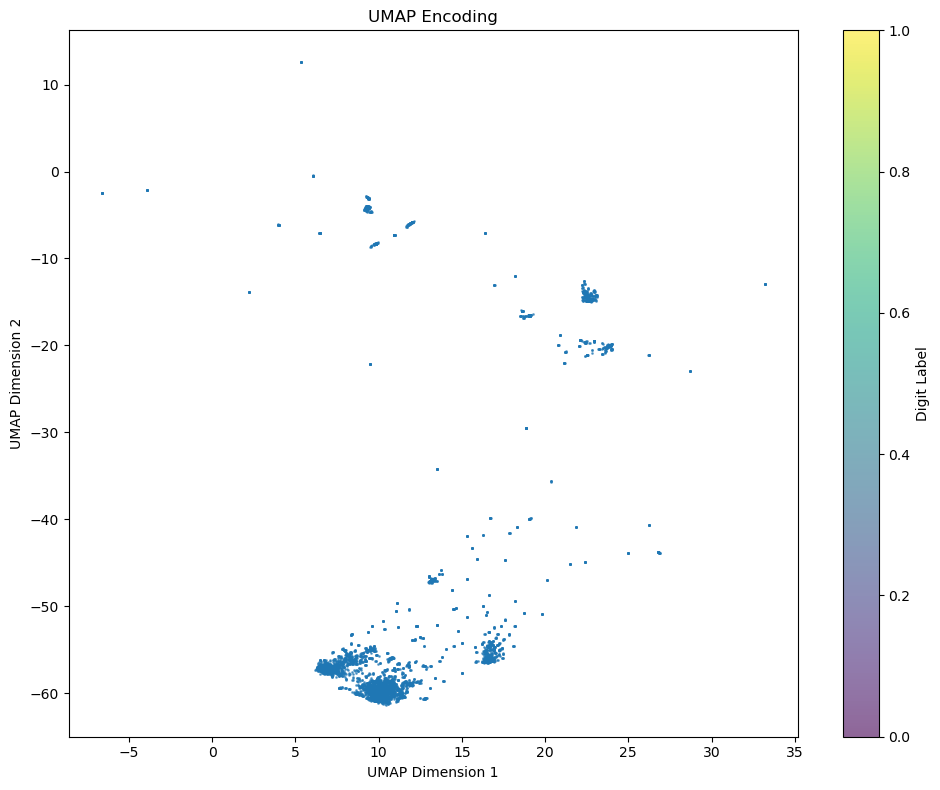

In [ ]:
importlib.reload(coderdata_processing)
from coderdata_processing import cat_cell_features_across_datasets

cell_features, cell_labels = cat_cell_features_across_datasets(binary_cell_dfs)

print(cell_features.shape)

umap = UMAP()
# umap = UMAP(n_neighbors=5, min_dist=0.01, random_state=42)
# Fit and transform the data
X_train_umap = umap.fit_transform(cell_features)

# Plot the results
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_train_umap[:, 0], X_train_umap[:, 1], cmap="Spectral", s=1, alpha=0.6)
plt.colorbar(scatter, label="Digit Label")
plt.title("UMAP Encoding")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
# Show the plot
plt.tight_layout()
plt.show()

In [ ]:
mutations = torch.from_numpy(cell_features).float()
cell_ids = torch.from_numpy(cell_labels).long()
mutation_dataset = TensorDataset(mutations, cell_ids)
torch.save({'X': mutations, 'y': cell_ids}, 'cell_mutations.pt')

In [7]:
importlib.reload(coderdata_processing)
from coderdata_processing import clean_experiments_across_dfs, dip_experiments_across_dfs

drugs_ref_dfs = {}
for name, data in selected_datasets.items():
    drugs_ref_dfs[name] = data.drugs.drop_duplicates(subset=["improve_drug_id"], inplace=False)

metric = "fit_auc"
experiments_dfs = clean_experiments_across_dfs(selected_datasets, metric=metric)

experiments_dfs_sampled = dip_experiments_across_dfs(experiments_dfs, fraction=0.01)

Dataset 'beataml': Cleaned 0 rows with NaN or infinite 'dose_response_value' values.
Dataset 'bladder': Cleaned 0 rows with NaN or infinite 'dose_response_value' values.
Dataset 'ccle': Cleaned 0 rows with NaN or infinite 'dose_response_value' values.
Dataset 'colorectal': Cleaned 0 rows with NaN or infinite 'dose_response_value' values.
Dataset 'ctrpv2': Cleaned 0 rows with NaN or infinite 'dose_response_value' values.
Dataset 'fimm': Cleaned 0 rows with NaN or infinite 'dose_response_value' values.
Dataset 'gcsi': Cleaned 0 rows with NaN or infinite 'dose_response_value' values.
Dataset 'gdscv1': Cleaned 0 rows with NaN or infinite 'dose_response_value' values.
Dataset 'gdscv2': Cleaned 0 rows with NaN or infinite 'dose_response_value' values.
Dataset 'liver': Cleaned 0 rows with NaN or infinite 'dose_response_value' values.
Dataset 'mpnst': Cleaned 0 rows with NaN or infinite 'dose_response_value' values.


/home/dzhao268/project/draft/DrugRes/src/coderdata_processing.py:155: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace([np.inf, -np.inf], np.nan)


Dataset 'nci60': Cleaned 26 rows with NaN or infinite 'dose_response_value' values.
Dataset 'pancreatic': Cleaned 0 rows with NaN or infinite 'dose_response_value' values.
Dataset 'prism': Cleaned 0 rows with NaN or infinite 'dose_response_value' values.


In [10]:
importlib.reload(coderdata_processing)
from coderdata_processing import preprocess_experiment_with_footprint

feature_dict_footprint, resp_footprint = preprocess_experiment_with_footprint(experiments_dfs_sampled, drugs_ref_dfs, dim_reduced_dfs, drug_target=None, show_status=True)

Processing dataset: beataml with 319 experiments
Skipping experiment 1668 with sample ID 2145 due to missing features in mutations_Frame_Shift_Ins
Skipping experiment 1668 with sample ID 2145 due to missing features in mutations_Missense_Mutation
Skipping experiment 1668 with sample ID 2145 due to missing features in mutations_Splice_Site
Skipping experiment 1668 with sample ID 2145 due to missing features in mutations_In_Frame_Ins
Skipping experiment 1668 with sample ID 2145 due to missing features in mutations_Frame_Shift_Del
Skipping experiment 1668 with sample ID 2145 due to missing features in mutations_Nonsense_Mutation
Skipping experiment 1668 with sample ID 2145 due to missing features in mutations_In_Frame_Del
Skipping experiment 1668 with sample ID 2145 due to missing features in mutations_Silent
Skipping experiment 2764 with sample ID 2266 due to missing features in mutations_Frame_Shift_Ins
Skipping experiment 2764 with sample ID 2266 due to missing features in mutations_Mi

[20:51:27] Explicit valence for atom # 0 Cl, 1, is greater than permitted


Skipping experiment 2702469 with sample ID 1808 due to missing features in mutations_Frame_Shift_Ins
Skipping experiment 2702469 with sample ID 1808 due to missing features in mutations_Missense_Mutation
Skipping experiment 2702469 with sample ID 1808 due to missing features in mutations_Splice_Site
Skipping experiment 2702469 with sample ID 1808 due to missing features in mutations_In_Frame_Ins
Skipping experiment 2702469 with sample ID 1808 due to missing features in mutations_Frame_Shift_Del
Skipping experiment 2702469 with sample ID 1808 due to missing features in mutations_Nonsense_Mutation
Skipping experiment 2702469 with sample ID 1808 due to missing features in mutations_In_Frame_Del
Skipping experiment 2702469 with sample ID 1808 due to missing features in mutations_Silent
Skipping experiment 2447908 with sample ID 1462 due to missing features in mutations_Frame_Shift_Ins
Skipping experiment 2447908 with sample ID 1462 due to missing features in mutations_Missense_Mutation
Ski

[20:51:55] WARNING: not removing hydrogen atom without neighbors


Skipping experiment 2627025 with sample ID 1806 due to missing features in mutations_Frame_Shift_Ins
Skipping experiment 2627025 with sample ID 1806 due to missing features in mutations_Missense_Mutation
Skipping experiment 2627025 with sample ID 1806 due to missing features in mutations_Splice_Site
Skipping experiment 2627025 with sample ID 1806 due to missing features in mutations_In_Frame_Ins
Skipping experiment 2627025 with sample ID 1806 due to missing features in mutations_Frame_Shift_Del
Skipping experiment 2627025 with sample ID 1806 due to missing features in mutations_Nonsense_Mutation
Skipping experiment 2627025 with sample ID 1806 due to missing features in mutations_In_Frame_Del
Skipping experiment 2627025 with sample ID 1806 due to missing features in mutations_Silent
Skipping experiment 204058 with sample ID 128 due to missing features in mutations_Frame_Shift_Ins
Skipping experiment 204058 with sample ID 128 due to missing features in mutations_Missense_Mutation
Skippin

[20:52:21] Explicit valence for atom # 13 N, 4, is greater than permitted


Skipping experiment 201271 with sample ID 128 due to missing features in mutations_Frame_Shift_Ins
Skipping experiment 201271 with sample ID 128 due to missing features in mutations_Missense_Mutation
Skipping experiment 201271 with sample ID 128 due to missing features in mutations_Splice_Site
Skipping experiment 201271 with sample ID 128 due to missing features in mutations_In_Frame_Ins
Skipping experiment 201271 with sample ID 128 due to missing features in mutations_Frame_Shift_Del
Skipping experiment 201271 with sample ID 128 due to missing features in mutations_Nonsense_Mutation
Skipping experiment 201271 with sample ID 128 due to missing features in mutations_In_Frame_Del
Skipping experiment 201271 with sample ID 128 due to missing features in mutations_Silent
Skipping experiment 2670350 with sample ID 1808 due to missing features in mutations_Frame_Shift_Ins
Skipping experiment 2670350 with sample ID 1808 due to missing features in mutations_Missense_Mutation
Skipping experiment

[20:52:54] Explicit valence for atom # 13 N, 4, is greater than permitted


Skipping experiment 2654149 with sample ID 1806 due to missing features in mutations_Frame_Shift_Ins
Skipping experiment 2654149 with sample ID 1806 due to missing features in mutations_Missense_Mutation
Skipping experiment 2654149 with sample ID 1806 due to missing features in mutations_Splice_Site
Skipping experiment 2654149 with sample ID 1806 due to missing features in mutations_In_Frame_Ins
Skipping experiment 2654149 with sample ID 1806 due to missing features in mutations_Frame_Shift_Del
Skipping experiment 2654149 with sample ID 1806 due to missing features in mutations_Nonsense_Mutation
Skipping experiment 2654149 with sample ID 1806 due to missing features in mutations_In_Frame_Del
Skipping experiment 2654149 with sample ID 1806 due to missing features in mutations_Silent
Skipping experiment 2461425 with sample ID 1462 due to missing features in mutations_Frame_Shift_Ins
Skipping experiment 2461425 with sample ID 1462 due to missing features in mutations_Missense_Mutation
Ski

In [18]:
for key in feature_dict_footprint.keys():
    print(f"Feature type: {key},  {feature_dict_footprint[key].keys()}")
    for feature_type in feature_dict_footprint[key].keys():
        print(f"  {feature_type}: shape {np.array(feature_dict_footprint[key][feature_type]).shape}")

Feature type: beataml,  dict_keys(['fingerprint', 'improve_sample_id', 'mutations_Frame_Shift_Ins', 'mutations_Missense_Mutation', 'mutations_Splice_Site', 'mutations_In_Frame_Ins', 'mutations_Frame_Shift_Del', 'mutations_Nonsense_Mutation', 'mutations_In_Frame_Del', 'mutations_Silent'])
  fingerprint: shape (298, 2048)
  improve_sample_id: shape (298,)
  mutations_Frame_Shift_Ins: shape (298, 14)
  mutations_Missense_Mutation: shape (298, 1887)
  mutations_Splice_Site: shape (298, 44)
  mutations_In_Frame_Ins: shape (298, 30)
  mutations_Frame_Shift_Del: shape (298, 39)
  mutations_Nonsense_Mutation: shape (298, 16)
  mutations_In_Frame_Del: shape (298, 55)
  mutations_Silent: shape (298, 668)
Feature type: bladder,  dict_keys(['fingerprint', 'improve_sample_id', 'mutations_Frame_Shift_Ins', 'mutations_Missense_Mutation', 'mutations_Splice_Site', 'mutations_In_Frame_Ins', 'mutations_Frame_Shift_Del', 'mutations_Nonsense_Mutation', 'mutations_In_Frame_Del', 'mutations_Silent'])
  finge

In [19]:
importlib.reload(coderdata_processing)
from coderdata_processing import cat_drug_response_features_across_datasets

feature_lst = list(dim_reduced_dfs.keys())

X, y = cat_drug_response_features_across_datasets(feature_dict_footprint, resp_footprint, unique_cell_ids_across_dfs, feature_lst)

ValueError: need at least one array to concatenate

In [12]:
print(X.shape)
umap = UMAP()
# umap = UMAP(n_neighbors=5, min_dist=0.01, random_state=42)
# Fit and transform the data
X_train_umap = umap.fit_transform(X)

# Plot the results
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_train_umap[:, 0], X_train_umap[:, 1], c=y, cmap="Spectral", s=1, alpha=0.6)
plt.colorbar(scatter, label="Digit Label")
plt.title("UMAP Encoding")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
# Show the plot
plt.tight_layout()
plt.show()

(26834, 1, 4801)


ValueError: Found array with dim 3, while dim <= 2 is required.

In [ ]:
cell_drug_pairs = torch.from_numpy(X).float()
responses = torch.from_numpy(y).float()
mutation_dataset = TensorDataset(cell_drug_pairs, responses)
torch.save({'X': cell_drug_pairs, 'y': responses}, 'cell_drug_response_samples.pt')